In [2]:
!mkdir -p /tmp/data
!tar -xf /scratch/rohitr_iitp/s2a.tar.gz -C /tmp/data/

In [1]:
!pip install rasterio tqdm

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import os
import glob
import numpy as np
import rasterio
from rasterio.enums import Resampling
from tqdm.notebook import tqdm

# --- UPDATED CONFIGURATION ---
# Added '/s2a' to the path so it looks in the right place
INPUT_ROOT = "/tmp/data/s2a"  
OUTPUT_ROOT = "/scratch/rohitr_iitp/processed_dataset"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Bands to stack: Blue, Green, Red, NIR, RedEdge
TARGET_BANDS = ['B02', 'B03', 'B04', 'B08', 'B8A']
TARGET_SHAPE = (132, 132) 

print(f"Scanning for scenes in: {INPUT_ROOT}")

# --- ROBUST SEARCH ---
# Look for B04 in .tif OR .jp2 format
scene_paths = glob.glob(os.path.join(INPUT_ROOT, "**", "*B04.tif"), recursive=True)
if not scene_paths:
    print("No .tif files found. Checking for .jp2...")
    scene_paths = glob.glob(os.path.join(INPUT_ROOT, "**", "*B04.jp2"), recursive=True)

print(f"Found {len(scene_paths)} scenes ready for processing.")

# --- PROCESSING LOOP ---
success_count = 0
fail_count = 0

for b04_path in tqdm(scene_paths, desc="Processing Scenes"):
    try:
        scene_folder = os.path.dirname(b04_path)
        # Use the folder name as the ID (e.g., T29SQB...)
        # We take the parent folder name to avoid confusion with nested Granule folders
        scene_name = os.path.basename(os.path.dirname(scene_folder)) 
        if scene_name == "IMG_DATA": # Handle standard SAFE structure
             scene_name = b04_path.split("/")[-4]

        stack = []
        for band in TARGET_BANDS:
            # Flexible search for .tif OR .jp2
            search = glob.glob(os.path.join(scene_folder, f"*{band}.*"))
            
            if not search:
                # Some datasets name files slightly differently (e.g., _B04_10m.jp2)
                # Try a looser match if exact match fails
                search = glob.glob(os.path.join(scene_folder, f"*{band}*.*"))
            
            if not search:
                raise FileNotFoundError(f"Band {band} missing in {scene_folder}")
            
            with rasterio.open(search[0]) as src:
                # Read and Resize to 132x132
                data = src.read(
                    1,
                    out_shape=TARGET_SHAPE,
                    resampling=Resampling.bilinear
                )
                stack.append(data)

        # Stack and Save
        full_cube = np.stack(stack, axis=-1).astype(np.uint16)
        save_path = os.path.join(OUTPUT_ROOT, f"{scene_name}.npy")
        np.save(save_path, full_cube)
        
        success_count += 1

    except Exception as e:
        print(f"Failed {scene_name}: {e}")
        fail_count += 1

print(f"\nDone! Processed: {success_count}, Failed: {fail_count}")
print(f"Output saved to: {OUTPUT_ROOT}")

Scanning for scenes in: /tmp/data/s2a
No .tif files found. Checking for .jp2...
Found 0 scenes ready for processing.


Processing Scenes: 0it [00:00, ?it/s]


Done! Processed: 0, Failed: 0
Output saved to: /scratch/rohitr_iitp/processed_dataset


In [5]:
import os

print("--- FILE SYSTEM EXPLORER ---")
start_dir = "/tmp/data"

found_any = False
# Walk through the directory tree
for root, dirs, files in os.walk(start_dir):
    # Filter for Sentinel images (either .tif or .jp2)
    images = [f for f in files if f.endswith('.tif') or f.endswith('.jp2')]
    
    if images:
        print(f"\nFOUND IMAGES IN: {root}")
        print(f"Example file: {images[0]}")
        found_any = True
        # Stop after finding the first valid folder to avoid flooding output
        break

if not found_any:
    print("\nCRITICAL: No .tif or .jp2 files found anywhere in /tmp/data!")
    print("Listing top-level folders in /tmp/data:")
    print(os.listdir(start_dir))

--- FILE SYSTEM EXPLORER ---

FOUND IMAGES IN: /tmp/data/s2a/003908/20200913T110701_20200913T111451_T29SQB
Example file: B8A.tif


In [6]:
import os
import glob
import numpy as np
import rasterio
from rasterio.enums import Resampling
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
# Point to the root of your extracted data
INPUT_ROOT = "/tmp/data/s2a"  
OUTPUT_ROOT = "/scratch/rohitr_iitp/processed_dataset"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Bands to stack: Blue, Green, Red, NIR, RedEdge
TARGET_BANDS = ['B02', 'B03', 'B04', 'B08', 'B8A']
TARGET_SHAPE = (132, 132) 

print(f"Scanning for scenes in: {INPUT_ROOT}")

# --- ROBUST SEARCH ---
# Look for B04.tif recursively. This finds the unique scenes.
scene_paths = glob.glob(os.path.join(INPUT_ROOT, "**", "*B04.tif"), recursive=True)
print(f"Found {len(scene_paths)} scenes ready for processing.")

# --- PROCESSING LOOP ---
success_count = 0
fail_count = 0

for b04_path in tqdm(scene_paths, desc="Processing Scenes"):
    try:
        # The folder containing the images is simply the parent of the B04 file
        scene_folder = os.path.dirname(b04_path)
        
        # Use the folder name as the ID (e.g., 20200913T110701_...)
        scene_name = os.path.basename(scene_folder)

        stack = []
        for band in TARGET_BANDS:
            # Look for the exact file (e.g., B02.tif) inside this specific folder
            # We use glob just in case there are slight naming variations
            search = glob.glob(os.path.join(scene_folder, f"*{band}.tif"))
            
            if not search:
                raise FileNotFoundError(f"Band {band}.tif missing in {scene_folder}")
            
            with rasterio.open(search[0]) as src:
                # Read and Resize to 132x132
                data = src.read(
                    1,
                    out_shape=TARGET_SHAPE,
                    resampling=Resampling.bilinear
                )
                stack.append(data)

        # Stack and Save
        full_cube = np.stack(stack, axis=-1).astype(np.uint16)
        save_path = os.path.join(OUTPUT_ROOT, f"{scene_name}.npy")
        np.save(save_path, full_cube)
        
        success_count += 1

    except Exception as e:
        print(f"Failed {scene_name}: {e}")
        fail_count += 1

print(f"\nDone! Processed: {success_count}, Failed: {fail_count}")
print(f"Output saved to: {OUTPUT_ROOT}")

Scanning for scenes in: /tmp/data/s2a
Found 0 scenes ready for processing.


Processing Scenes: 0it [00:00, ?it/s]


Done! Processed: 0, Failed: 0
Output saved to: /scratch/rohitr_iitp/processed_dataset


In [7]:
import os
import glob
import numpy as np
import rasterio
from rasterio.enums import Resampling
from tqdm.notebook import tqdm

# 1. Inspect the specific folder we found earlier
known_folder = "/tmp/data/s2a/003908/20200913T110701_20200913T111451_T29SQB"

print(f"--- INSPECTING FOLDER: {known_folder} ---")
if os.path.exists(known_folder):
    files = sorted(os.listdir(known_folder))
    print("Files found (First 10):")
    print(files[:10])
    
    # 2. INTELLIGENT BAND MAPPING
    # We will try to find the files that correspond to our target bands
    # Dictionary to map 'Standard Name' -> 'Actual Filename'
    band_map = {}
    targets = {
        'B02': ['B02', 'B2'],       # Blue
        'B03': ['B03', 'B3'],       # Green
        'B04': ['B04', 'B4'],       # Red
        'B08': ['B08', 'B8'],       # NIR
        'B8A': ['B8A']              # RedEdge
    }
    
    print("\n--- ATTEMPTING TO MAP BANDS ---")
    for standard_name, possible_names in targets.items():
        match_found = False
        for f in files:
            # Check if any identifier (e.g. "B04") is in the filename
            if any(id_str in f for id_str in possible_names) and (f.endswith('.tif') or f.endswith('.jp2')):
                band_map[standard_name] = f
                match_found = True
                break
        
        if match_found:
            print(f"  {standard_name}  ->  {band_map[standard_name]}")
        else:
            print(f"  {standard_name}  ->  MISSING!")

else:
    print("CRITICAL: The known folder path does not exist. Did /tmp get wiped?")
    band_map = {}

# 3. IF MAPPING SUCCEEDED, RUN PROCESSING
if len(band_map) == 5:
    print("\n--- MAPPING SUCCESSFUL! STARTING PROCESSING ---")
    
    OUTPUT_ROOT = "/scratch/rohitr_iitp/processed_dataset"
    os.makedirs(OUTPUT_ROOT, exist_ok=True)
    target_shape = (132, 132)
    
    # Process JUST this one scene first to prove it works
    try:
        stack = []
        for b in ['B02', 'B03', 'B04', 'B08', 'B8A']:
            file_path = os.path.join(known_folder, band_map[b])
            with rasterio.open(file_path) as src:
                data = src.read(1, out_shape=target_shape, resampling=Resampling.bilinear)
                stack.append(data)
        
        full_cube = np.stack(stack, axis=-1).astype(np.uint16)
        save_name = os.path.join(OUTPUT_ROOT, "TEST_SCENE.npy")
        np.save(save_name, full_cube)
        print(f"SUCCESS: Saved {save_name} with shape {full_cube.shape}")
        
    except Exception as e:
        print(f"Processing failed: {e}")

else:
    print("\nSTOPPING: Could not find all 5 bands. Check the file list above.")

--- INSPECTING FOLDER: /tmp/data/s2a/003908/20200913T110701_20200913T111451_T29SQB ---
Files found (First 10):
['B1.tif', 'B11.tif', 'B12.tif', 'B2.tif', 'B3.tif', 'B4.tif', 'B5.tif', 'B6.tif', 'B7.tif', 'B8.tif']

--- ATTEMPTING TO MAP BANDS ---
  B02  ->  B2.tif
  B03  ->  B3.tif
  B04  ->  B4.tif
  B08  ->  B8.tif
  B8A  ->  B8A.tif

--- MAPPING SUCCESSFUL! STARTING PROCESSING ---
SUCCESS: Saved /scratch/rohitr_iitp/processed_dataset/TEST_SCENE.npy with shape (132, 132, 5)


In [8]:
import os
import glob
import numpy as np
import rasterio
from rasterio.enums import Resampling
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
INPUT_ROOT = "/tmp/data/s2a"
OUTPUT_ROOT = "/scratch/rohitr_iitp/processed_dataset"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Target resolution for all bands
TARGET_SHAPE = (132, 132) 

# Explicit mapping based on your directory structure
BAND_FILES = {
    'B02': 'B2.tif',
    'B03': 'B3.tif',
    'B04': 'B4.tif',
    'B08': 'B8.tif',
    'B8A': 'B8A.tif'
}

print(f"Scanning for scenes in: {INPUT_ROOT}")

# Find all scenes by looking for the Red band (B4.tif)
# We use recursive glob to find every occurrence of B4.tif
scene_paths = glob.glob(os.path.join(INPUT_ROOT, "**", "B4.tif"), recursive=True)
print(f"Found {len(scene_paths)} scenes ready for processing.")

# --- PROCESSING LOOP ---
success_count = 0
fail_count = 0

for b4_path in tqdm(scene_paths, desc="Processing Scenes"):
    try:
        # Get the folder containing the bands
        scene_folder = os.path.dirname(b4_path)
        
        # Use the folder name as the Scene ID
        scene_name = os.path.basename(scene_folder)
        
        stack = []
        # Load exactly the 5 bands we need
        for band_code, filename in BAND_FILES.items():
            file_path = os.path.join(scene_folder, filename)
            
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"Missing {filename} in {scene_name}")
            
            with rasterio.open(file_path) as src:
                # Read and Resize (B8A is 20m, others are 10m -> all become 132x132)
                data = src.read(
                    1,
                    out_shape=TARGET_SHAPE,
                    resampling=Resampling.bilinear
                )
                stack.append(data)

        # Stack into (132, 132, 5) and convert to uint16
        full_cube = np.stack(stack, axis=-1).astype(np.uint16)
        
        # Save compressed .npy to Scratch
        save_path = os.path.join(OUTPUT_ROOT, f"{scene_name}.npy")
        np.save(save_path, full_cube)
        
        success_count += 1

    except Exception as e:
        print(f"Failed {scene_name}: {e}")
        fail_count += 1

print(f"\nProcessing Complete!")
print(f"Successful: {success_count}")
print(f"Failed: {fail_count}")
print(f"Data saved to: {OUTPUT_ROOT}")

Scanning for scenes in: /tmp/data/s2a
Found 166775 scenes ready for processing.


Processing Scenes:   0%|          | 0/166775 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [9]:
!pip install joblib

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import os
import glob
import numpy as np
import rasterio
from rasterio.enums import Resampling
from joblib import Parallel, delayed, cpu_count
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
INPUT_ROOT = "/tmp/data/s2a"
OUTPUT_ROOT = "/scratch/rohitr_iitp/processed_dataset"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

TARGET_SHAPE = (132, 132) 
BAND_FILES = {'B02': 'B2.tif', 'B03': 'B3.tif', 'B04': 'B4.tif', 'B08': 'B8.tif', 'B8A': 'B8A.tif'}

# --- FIND SCENES ---
print(f"Scanning for scenes in: {INPUT_ROOT}")
scene_paths = glob.glob(os.path.join(INPUT_ROOT, "**", "B4.tif"), recursive=True)
print(f"Found {len(scene_paths)} scenes.")

# --- THE WORKER FUNCTION ---
def process_single_scene(b4_path):
    try:
        scene_folder = os.path.dirname(b4_path)
        scene_name = os.path.basename(scene_folder)
        save_path = os.path.join(OUTPUT_ROOT, f"{scene_name}.npy")
        
        # SKIP if already done (Resume capability)
        if os.path.exists(save_path):
            return 0 # 0 means "Skipped"

        stack = []
        for band_code, filename in BAND_FILES.items():
            file_path = os.path.join(scene_folder, filename)
            
            # Fast fail if file missing
            if not os.path.exists(file_path):
                return -1 # Error
            
            with rasterio.open(file_path) as src:
                data = src.read(1, out_shape=TARGET_SHAPE, resampling=Resampling.bilinear)
                stack.append(data)

        full_cube = np.stack(stack, axis=-1).astype(np.uint16)
        np.save(save_path, full_cube)
        return 1 # Success

    except Exception:
        return -1 # Error

# --- PARALLEL EXECUTION ---
# n_jobs=-1 uses ALL available cores
n_cores = cpu_count()
print(f"Starting Parallel Processing on {n_cores} CPU cores...")

results = Parallel(n_jobs=-1, verbose=5)(
    delayed(process_single_scene)(p) for p in tqdm(scene_paths, desc="Processing")
)

# --- SUMMARY ---
processed = results.count(1)
skipped = results.count(0)
failed = results.count(-1)

print(f"\nDONE! Processed: {processed}, Skipped: {skipped}, Failed: {failed}")
print(f"Data saved to: {OUTPUT_ROOT}")

Scanning for scenes in: /tmp/data/s2a
Found 166775 scenes.
Starting Parallel Processing on 32 CPU cores...


Processing:   0%|          | 0/166775 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 384 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 2112 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 8448 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 15936 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 24576 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 34368 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done 45312 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 57408 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 70656 tasks      | elapsed:   17.5s
[Parallel(n_jobs=-1)]: Done 85056 tasks      | elapsed:   19.8s
[Parallel(n_jobs=-1)]: Done 100608 tasks      | elapsed:   22.1s
[Parallel(n_jobs=-1)]: Done 117312 tasks      | elapsed:   24.4s
[Parallel(n_jobs=-1)]: Done 13516


DONE! Processed: 77071, Skipped: 89704, Failed: 0
Data saved to: /scratch/rohitr_iitp/processed_dataset


[Parallel(n_jobs=-1)]: Done 166775 out of 166775 | elapsed:   30.3s finished


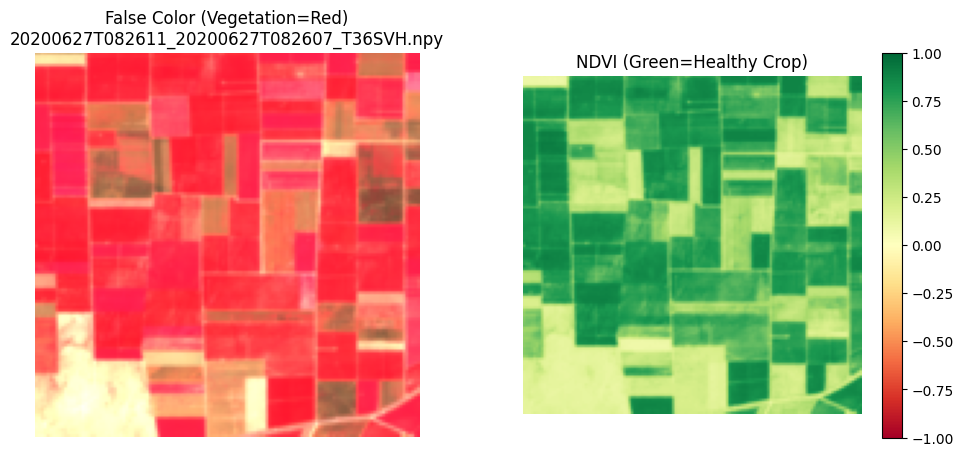

Successfully loaded 20200627T082611_20200627T082607_T36SVH.npy
Shape: (132, 132, 5), Dtype: float64


In [7]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Configuration
OUTPUT_ROOT = "/scratch/rohitr_iitp/processed_dataset"
files = os.listdir(OUTPUT_ROOT)

if not files:
    print("Error: No files found!")
else:
    # Pick a random scene to test
    test_file = random.choice(files)
    path = os.path.join(OUTPUT_ROOT, test_file)
    
    # Load the cube (132, 132, 5)
    cube = np.load(path).astype(float)
    
    # Band Mapping: 0:Blue, 1:Green, 2:Red, 3:NIR, 4:RedEdge
    # Create False Color (NIR, Red, Green) -> Vegetation appears Red
    false_color = np.dstack((cube[:,:,3], cube[:,:,2], cube[:,:,1]))
    # Normalize to 0-1 range for display (assuming max value ~3000 for Sentinel-2)
    false_color = np.clip(false_color / 3000.0, 0, 1)
    
    # Calculate NDVI: (NIR - Red) / (NIR + Red)
    nir = cube[:,:,3]
    red = cube[:,:,2]
    ndvi = (nir - red) / (nir + red + 1e-8)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    ax[0].imshow(false_color)
    ax[0].set_title(f"False Color (Vegetation=Red)\n{test_file}")
    ax[0].axis('off')
    
    im = ax[1].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax[1].set_title("NDVI (Green=Healthy Crop)")
    ax[1].axis('off')
    plt.colorbar(im, ax=ax[1])
    
    plt.show()
    print(f"Successfully loaded {test_file}")
    print(f"Shape: {cube.shape}, Dtype: {cube.dtype}")

In [5]:
import shutil
shutil.rmtree("/tmp/data", ignore_errors=True)
print("Node clean.")

Node clean.


In [8]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --- CONFIGURATION ---
DATA_DIR = "/tmp/fast_data"
BATCH_SIZE = 64  # SSL benefits from larger batches (try 128 or 256 if memory allows)
NUM_WORKERS = 4 

class AgriSSLDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.file_list = glob.glob(os.path.join(data_dir, "*.npy"))
        self.transform = transform
        
        if len(self.file_list) == 0:
            print(f"CRITICAL WARNING: No files found in {data_dir}")

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path = self.file_list[idx]
        
        try:
            # 1. Load Data
            image = np.load(path).astype(np.float32)
            
            # 2. Min-Max Normalization
            image = np.clip(image, 0, 3000)
            image = image / 3000.0
            
            # 3. To Tensor
            image = torch.from_numpy(image).permute(2, 0, 1)

            # 4. Augment
            if self.transform:
                return self.transform(image)
            return image

        except Exception as e:
            # FALLBACK STRATEGY
            # If loading fails, pick a random valid index and try again
            # This prevents one bad file from killing the whole training run
            print(f"Warning: Corrupt file at {path}. Skipping...")
            new_idx = np.random.randint(0, len(self.file_list))
            return self.__getitem__(new_idx)

In [9]:
# --- AUGMENTATION PIPELINE ---
# Simple spatial transforms are safe for hyperspectral data
ssl_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    # You could add RandomResizedCrop here for SimCLR
])

# --- INITIALIZE LOADERS ---
# We use the whole dataset for training since we have no labels to validate against yet.
dataset = AgriSSLDataset(DATA_DIR, transform=ssl_transforms)

# Speed tip: pin_memory=True and num_workers=4 speeds up data transfer to GPU
train_loader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,
    drop_last=True # Important for SSL to keep batch statistics stable
)

print(f"SSL Dataset Ready.")
print(f"Total Images: {len(dataset)}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Batches per Epoch: {len(train_loader)}")

CRITICAL WARNING: No files found in /tmp/fast_data


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [10]:
# Grab one batch
images = next(iter(train_loader))

print("\n--- BATCH INSPECTION ---")
print(f"Tensor Shape: {images.shape}")
print(f"Expected:     ({BATCH_SIZE}, 5, 132, 132)")
print(f"Data Type:    {images.dtype}")
print(f"Min Value:    {images.min():.4f}")
print(f"Max Value:    {images.max():.4f}")

if images.shape[1] == 5:
    print("\nSUCCESS: Data is ready for the model!")
else:
    print("\nERROR: Channels are wrong. Check the permute/transpose logic.")

NameError: name 'train_loader' is not defined

In [7]:
import torch
import torch.nn as nn
from torchvision import transforms, models

# --- 1. DEFINE AUGMENTATIONS ---
# We use RandomResizedCrop (Scale Invariance) and Flips (Rotational Invariance)
# Note: We CANNOT use ColorJitter because it only supports 3 channels.
class SimCLRTransform:
    def __init__(self, size=132):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(size=size, scale=(0.5, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            # Add Gaussian Noise (optional, good for sensors)
        ])

    def __call__(self, x):
        # Apply the transform twice to the SAME image
        return self.transform(x), self.transform(x)

# --- 2. UPDATE DATASET ---
# Re-initialize dataset with the SimCLR wrapper
# Assuming 'AgriSSLDataset' and 'DATA_DIR' are defined from previous cells
simclr_transform = SimCLRTransform(size=132)
train_dataset = AgriSSLDataset(DATA_DIR, transform=simclr_transform)

train_loader = DataLoader(
    train_dataset, 
    batch_size=64,  # Larger is better for SimCLR (try 128 if GPU allows)
    shuffle=True, 
    num_workers=4, 
    pin_memory=True,
    drop_last=True
)

print("SimCLR Data Pipeline Ready.")
# Verify: Get a batch
v1, v2 = next(iter(train_loader))
print(f"View 1 Shape: {v1.shape}")
print(f"View 2 Shape: {v2.shape}")

SimCLR Data Pipeline Ready.
View 1 Shape: torch.Size([64, 5, 132, 132])
View 2 Shape: torch.Size([64, 5, 132, 132])


In [8]:
import torch.nn.functional as F

class SimCLR(nn.Module):
    def __init__(self, base_model='resnet18', out_dim=128):
        super(SimCLR, self).__init__()
        
        # Load standard ResNet
        self.backbone = models.resnet18(pretrained=False)
        
        # MODIFICATION 1: 5-Channel Input
        # Original: nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone.conv1 = nn.Conv2d(
            in_channels=5, 
            out_channels=64, 
            kernel_size=7, 
            stride=2, 
            padding=3, 
            bias=False
        )
        
        # Remove the original fully connected layer (fc)
        dim_mlp = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        
        # MODIFICATION 2: Projection Head
        # The head maps representations to the space where loss is calculated
        self.projection_head = nn.Sequential(
            nn.Linear(dim_mlp, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim)
        )

    def forward(self, x):
        # Get representation (h)
        h = self.backbone(x)
        # Get projection (z)
        z = self.projection_head(h)
        return h, z

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimCLR().to(device)

print(f"Model initialized on {device}")

Model initialized on cuda


/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [9]:
class NTXentLoss(nn.Module):
    def __init__(self, batch_size, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.batch_size = batch_size
        self.temperature = temperature
        self.mask = self.mask_correlated_samples(batch_size)
        self.criterion = nn.CrossEntropyLoss(reduction="sum")
        self.similarity_f = nn.CosineSimilarity(dim=2)

    def mask_correlated_samples(self, batch_size):
        N = 2 * batch_size
        mask = torch.ones((N, N), dtype=bool)
        mask = mask.fill_diagonal_(0)
        for i in range(batch_size):
            mask[i, batch_size + i] = 0
            mask[batch_size + i, i] = 0
        return mask

    def forward(self, z_i, z_j):
        """
        z_i, z_j: Output projections of the two views
        """
        N = 2 * self.batch_size
        z = torch.cat((z_i, z_j), dim=0)
        
        # Calculate Similarity Matrix
        sim = self.similarity_f(z.unsqueeze(1), z.unsqueeze(0)) / self.temperature
        
        # Positive Pairs (Diagonals shifted by batch_size)
        sim_i_j = torch.diag(sim, self.batch_size)
        sim_j_i = torch.diag(sim, -self.batch_size)
        
        # We only want positive pairs for the numerator
        positive_samples = torch.cat((sim_i_j, sim_j_i), dim=0).reshape(N, 1)
        
        # For the denominator, we need all NEGATIVE pairs
        # We mask out the self-similarity and the positive pair similarity
        mask = self.mask.to(z.device)
        negative_samples = sim[mask].reshape(N, -1)
        
        labels = torch.zeros(N).to(positive_samples.device).long()
        logits = torch.cat((positive_samples, negative_samples), dim=1)
        
        loss = self.criterion(logits, labels)
        return loss / N

print("Loss Function Defined.")

Loss Function Defined.


In [2]:
import os
import shutil
import glob
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# --- CONFIG ---
SOURCE_DIR = "/scratch/rohitr_iitp/processed_dataset"
DEST_DIR = "/tmp/fast_data"
os.makedirs(DEST_DIR, exist_ok=True)

# 1. Get list of all files (Fast)
print("Indexing files...")
files = glob.glob(os.path.join(SOURCE_DIR, "*.npy"))
print(f"Found {len(files)} files to copy.")

# 2. Define the worker function
def copy_fast(src_path):
    filename = os.path.basename(src_path)
    dst_path = os.path.join(DEST_DIR, filename)
    
    # Skip if already exists (Resume capability)
    if not os.path.exists(dst_path):
        shutil.copy2(src_path, dst_path)

# 3. Run in Parallel (Uses all CPU cores)
print(f"Starting Parallel Copy to {DEST_DIR}...")
Parallel(n_jobs=-1, verbose=0)(
    delayed(copy_fast)(f) for f in tqdm(files, desc="Copying")
)

print("Copy Complete! You can now train.")

Indexing files...
Found 79057 files to copy.
Starting Parallel Copy to /tmp/fast_data...


Copying:   0%|          | 0/79057 [00:00<?, ?it/s]

Copy Complete! You can now train.


In [17]:
import torch.optim as optim
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
EPOCHS = 10 
LEARNING_RATE = 1e-3
TEMP = 0.5
SAVE_DIR = "/scratch/rohitr_iitp/models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Initialize Loss and Optimizer
loss_fn = NTXentLoss(batch_size=64, temperature=TEMP)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Starting Training for {EPOCHS} Epochs...")
print(f"Saving checkpoints to: {SAVE_DIR}")

# --- TRAIN LOOP ---
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for i, (view1, view2) in enumerate(progress_bar):
        view1 = view1.to(device)
        view2 = view2.to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass (Get projections z)
        _, z1 = model(view1)
        _, z2 = model(view2)
        
        # Calculate Loss
        loss = loss_fn(z1, z2)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Update progress bar every 10 batches
        if i % 10 == 0:
            progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} Complete. Avg Loss: {avg_loss:.4f}")
    
    # Save Checkpoint
    save_path = os.path.join(SAVE_DIR, f"simclr_resnet18_epoch_{epoch+1}.pth")
    torch.save(model.state_dict(), save_path)
    print(f"Saved: {save_path}")

print("Training Complete!")

Starting Training for 10 Epochs...
Saving checkpoints to: /scratch/rohitr_iitp/models


Epoch 1/10:   0%|          | 0/1235 [00:00<?, ?it/s]

Epoch 1 Complete. Avg Loss: 3.0240
Saved: /scratch/rohitr_iitp/models/simclr_resnet18_epoch_1.pth


Epoch 2/10:   0%|          | 0/1235 [00:00<?, ?it/s]

Epoch 2 Complete. Avg Loss: 2.9772
Saved: /scratch/rohitr_iitp/models/simclr_resnet18_epoch_2.pth


...

Epoch 8 Complete. Avg Loss: 2.9292
Saved: /scratch/rohitr_iitp/models/simclr_resnet18_epoch_8.pth


Epoch 9/10:   0%|          | 0/1235 [00:00<?, ?it/s]

Epoch 9 Complete. Avg Loss: 2.9271
Saved: /scratch/rohitr_iitp/models/simclr_resnet18_epoch_9.pth


Epoch 10/10:   0%|          | 0/1235 [00:00<?, ?it/s]

Epoch 10 Complete. Avg Loss: 2.9277
Saved: /scratch/rohitr_iitp/models/simclr_resnet18_epoch_10.pth
Training Complete!


In [10]:
import os
import glob
import numpy as np
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# --- CONFIG ---
# Make sure this matches where your loader is pointing!
# Use "/tmp/fast_data" if you copied it, or "/scratch/rohitr_iitp/processed_dataset" if not.
DATA_DIR = "/tmp/fast_data" 

print(f"Scanning {DATA_DIR} for corrupt files...")
files = glob.glob(os.path.join(DATA_DIR, "*.npy"))

def check_and_remove(path):
    try:
        # Try to load just the header/metadata to check validity
        np.load(path, mmap_mode='r')
    except Exception:
        # If it fails, delete it
        try:
            os.remove(path)
            return 1 # Found and deleted a bad file
        except:
            return 0
    return 0

# Run in parallel to check 166k files in seconds
bad_files = Parallel(n_jobs=-1, verbose=0)(
    delayed(check_and_remove)(f) for f in tqdm(files, desc="Sanitizing")
)

print(f"\nDone! Deleted {sum(bad_files)} corrupt files.")

Scanning /tmp/fast_data for corrupt files...


Sanitizing:   0%|          | 0/79057 [00:00<?, ?it/s]


Done! Deleted 3 corrupt files.


In [10]:
import torch
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader

# --- CONFIGURATION ---
# Use the same path you used for training
DATA_DIR = "/tmp/fast_data" 
# Path to your BEST saved model (check /scratch/rohitr_iitp/models/)
CHECKPOINT_PATH = "/scratch/rohitr_iitp/models/simclr_resnet18_epoch_10.pth" 
BATCH_SIZE = 64

# --- 1. LOAD TRAINED BACKBONE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-initialize the model structure
model = SimCLR().to(device) # Uses the class we defined earlier

# Load weights
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint)

# Remove the Projection Head - we only want the ResNet backbone
# The output of model.backbone(x) is the feature vector
model.eval()

# --- 2. DATA LOADER FOR INFERENCE ---
# We need a simple loader that returns (image, filename) so we can map IDs
class InferenceDataset(Dataset):
    def __init__(self, data_dir):
        self.file_list = glob.glob(os.path.join(data_dir, "*.npy"))
    
    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path = self.file_list[idx]
        filename = os.path.basename(path).replace('.npy', '')
        
        try:
            image = np.load(path).astype(np.float32)
            image = np.clip(image, 0, 3000) / 3000.0
            image = torch.from_numpy(image).permute(2, 0, 1)
            return image, filename
        except:
            # Return dummy if failed (shouldn't happen after sanitizing)
            return torch.zeros(5, 132, 132), filename

inf_dataset = InferenceDataset(DATA_DIR)
inf_loader = DataLoader(inf_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# --- 3. EXTRACT FEATURES ---
print("Extracting features...")
features_list = []
filenames_list = []

with torch.no_grad():
    for images, fnames in tqdm(inf_loader):
        images = images.to(device)
        
        # Get features from backbone
        # ResNet18 backbone output is usually (Batch, 512, 1, 1) -> Flatten to (Batch, 512)
        feats = model.backbone(images)
        feats = torch.flatten(feats, 1)
        
        features_list.append(feats.cpu().numpy())
        filenames_list.extend(fnames)

# Concatenate all batches
X = np.concatenate(features_list, axis=0)
print(f"Extraction Complete. Feature Matrix Shape: {X.shape}")
# Expected: (Total_Images, 512)

Extracting features...


  0%|          | 0/1236 [00:00<?, ?it/s]

/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1708025831440/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Extraction Complete. Feature Matrix Shape: (79054, 512)


In [11]:
from sklearn.cluster import KMeans

# --- CONFIGURATION ---
NUM_CLUSTERS = 3  # Change this based on your competition rules!

print(f"Clustering into {NUM_CLUSTERS} classes using K-Means...")

# Initialize K-Means
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)

# Fit and Predict
labels = kmeans.fit_predict(X)

print("Clustering Done!")
# Check distribution (are classes balanced?)
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

Clustering into 3 classes using K-Means...
Clustering Done!
{0: 25017, 1: 11153, 2: 42884}


In [12]:
df = pd.DataFrame({'id': filenames_list, 'cluster': labels})

print("Clustering Complete.")
print("Counts per cluster:")
print(df['cluster'].value_counts())

Clustering Complete.
Counts per cluster:
cluster
2    42884
0    25017
1    11153
Name: count, dtype: int64


Inspect these images to name your clusters:


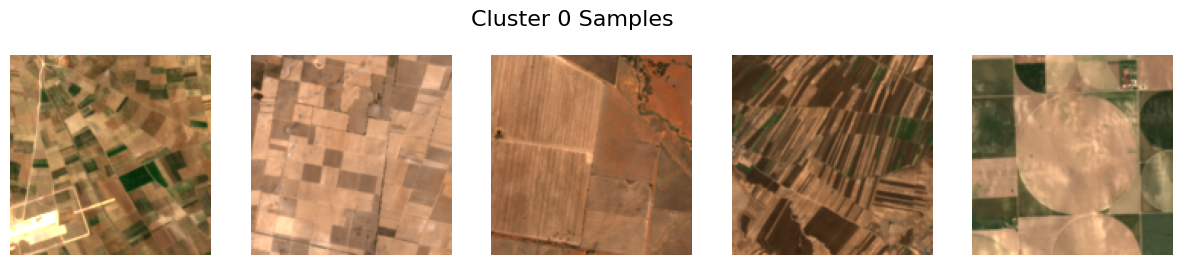

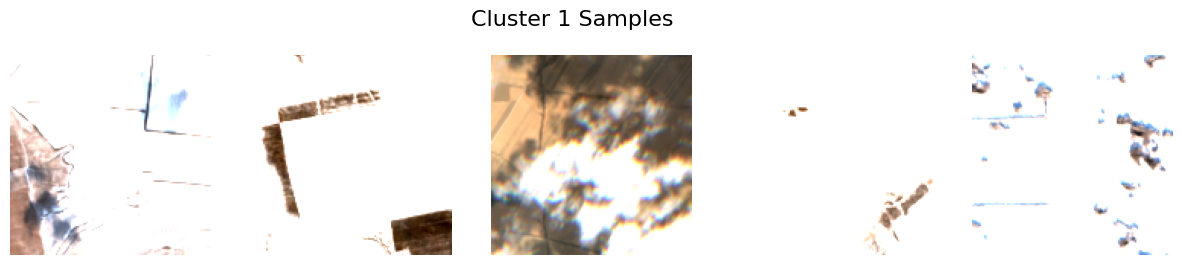

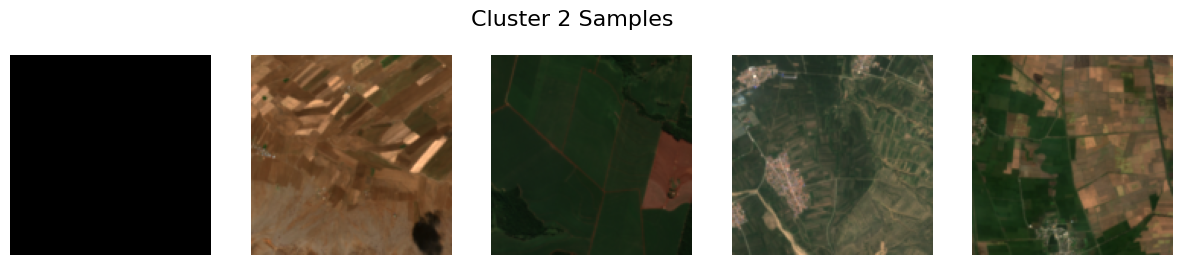

In [13]:
import matplotlib.pyplot as plt
import random

def show_cluster_samples(cluster_id):
    # Get filenames for this cluster
    sample_ids = df[df['cluster'] == cluster_id]['id'].sample(5).values
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f"Cluster {cluster_id} Samples", fontsize=16)
    
    for i, file_id in enumerate(sample_ids):
        # Reconstruct path (assuming data is in /tmp/fast_data)
        path = os.path.join(DATA_DIR, f"{file_id}.npy")
        
        try:
            # Load and Prep RGB (Bands: B04=Red, B03=Green, B02=Blue)
            # Index in our 5-channel cube: 0=Blue, 1=Green, 2=Red, 3=NIR, 4=RedEdge
            cube = np.load(path).astype(float)
            
            # Create True Color RGB (Red, Green, Blue)
            rgb = np.dstack((cube[:,:,2], cube[:,:,1], cube[:,:,0]))
            
            # Normalize for display (Sentinel-2 usually max ~3000)
            rgb = np.clip(rgb / 3000.0, 0, 1)
            
            axes[i].imshow(rgb)
            axes[i].axis('off')
        except:
            pass
    plt.show()

# Show all 3 clusters
print("Inspect these images to name your clusters:")
for c in range(3):
    show_cluster_samples(c)

In [14]:
# --- USER INPUT REQUIRED ---
# Update this based on your visual inspection above!
cluster_mapping = {
    0: 'other',  # CHANGE THIS based on what you see!
    1: 'rust',     # CHANGE THIS
    2: 'healthy'     # CHANGE THIS
}

# Apply the mapping
df['label'] = df['cluster'].map(cluster_mapping)

# Check if it looks right
print(df.head())

# Save final submission
df[['id', 'label']].to_csv("/scratch/rohitr_iitp/submission.csv", index=False)
print("Submission saved to /scratch/rohitr_iitp/submission.csv")

                                       id  cluster    label
0  20201108T014701_20201108T014747_T51HUC        0    other
1  20200229T061801_20200229T061830_T42UYE        1     rust
2  20201122T021349_20201122T021555_T50JLP        0    other
3  20200703T184921_20200703T185812_T11TMM        2  healthy
4  20201116T055121_20201116T055120_T44UNC        1     rust
Submission saved to /scratch/rohitr_iitp/submission.csv


Running t-SNE... (This might take a minute)


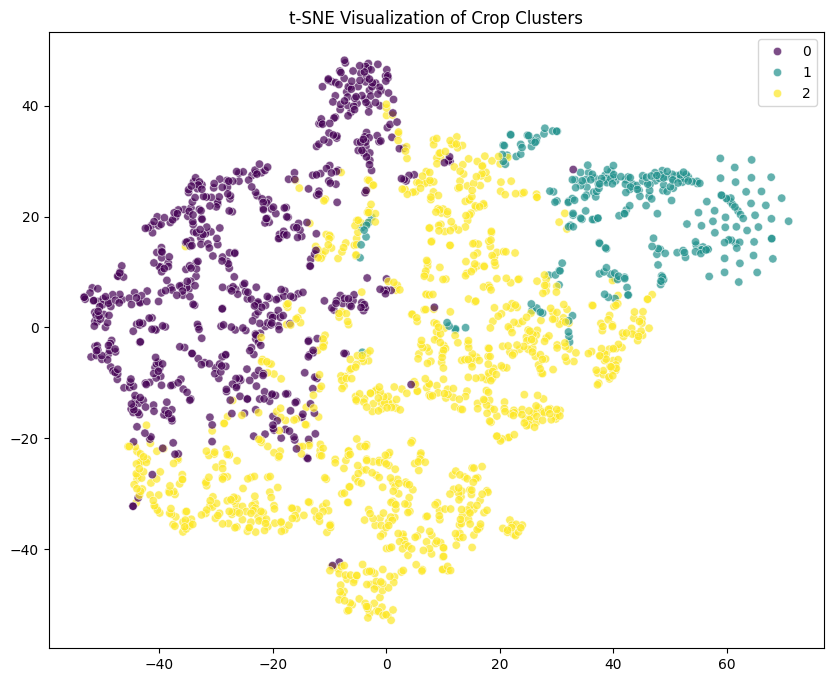

In [15]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

print("Running t-SNE... (This might take a minute)")
# We use a subset of 2000 images to make it fast
subset_indices = np.random.choice(len(X), size=min(2000, len(X)), replace=False)
X_subset = X[subset_indices]
labels_subset = labels[subset_indices] # The K-Means labels you just generated

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X_subset)

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_embedded[:, 0], 
    y=X_embedded[:, 1], 
    hue=labels_subset, 
    palette="viridis", 
    legend="full",
    alpha=0.7
)
plt.title("t-SNE Visualization of Crop Clusters")
plt.show()

In [16]:
from sklearn.metrics import silhouette_score

# Calculate score on the same subset
score = silhouette_score(X_subset, labels_subset)
print(f"Silhouette Score: {score:.4f}")

if score > 0.2:
    print("Verdict: Decent separation. The model found structure.")
elif score > 0.5:
    print("Verdict: Excellent separation! distinct classes found.")
else:
    print("Verdict: Poor separation. The clusters are very mixed.")

Silhouette Score: 0.0653
Verdict: Poor separation. The clusters are very mixed.


In [17]:
# Check purity of Cluster 0
print("--- CHECKING CLUSTER 0 PURITY ---")
cluster0_ids = df[df['cluster'] == 0]['id'].sample(10).values

for fid in cluster0_ids:
    # Just print the ID, or use the plotting function I gave you earlier to see them
    print(f"Image {fid} -> Assigned to Cluster 0")

--- CHECKING CLUSTER 0 PURITY ---
Image 20200711T180921_20200711T182122_T12STC -> Assigned to Cluster 0
Image 20200619T022601_20200619T022555_T51SYB -> Assigned to Cluster 0
Image 20200420T134209_20200420T134205_T21JXJ -> Assigned to Cluster 0
Image 20201223T172731_20201223T173415_T13QFG -> Assigned to Cluster 0
Image 20200908T110619_20200908T111404_T30STG -> Assigned to Cluster 0
Image 20210515T072621_20210515T073147_T38SQA -> Assigned to Cluster 0
Image 20200809T110629_20200809T111347_T29SPS -> Assigned to Cluster 0
Image 20210713T061631_20210713T062013_T41SQC -> Assigned to Cluster 0
Image 20200715T110621_20200715T110914_T29SQC -> Assigned to Cluster 0
Image 20200805T171901_20200805T172644_T14RLV -> Assigned to Cluster 0


Generating plots for all 3 clusters...
Look for: Bright Red = Healthy, Dull/Brown = Rust, Blue/Grey = Other


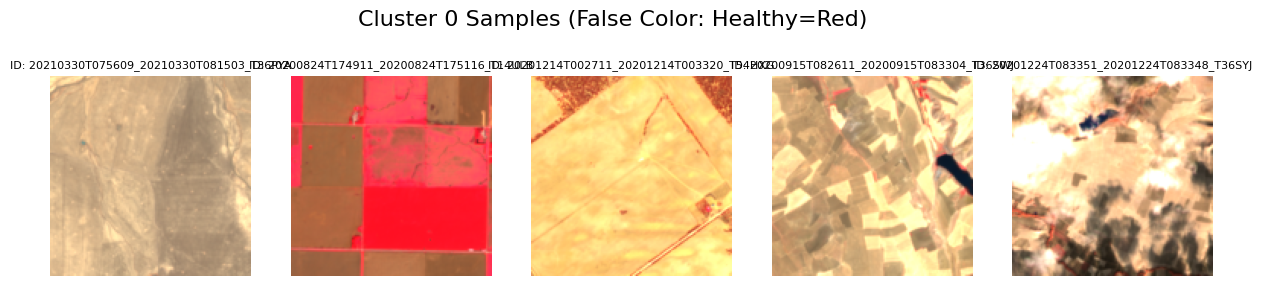

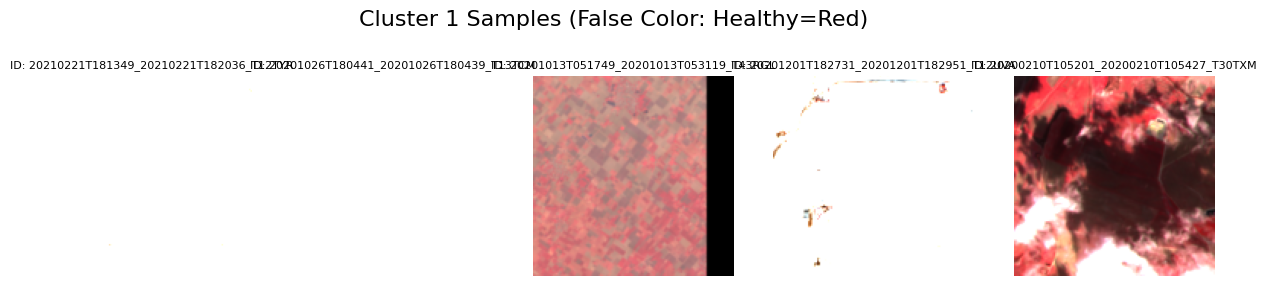

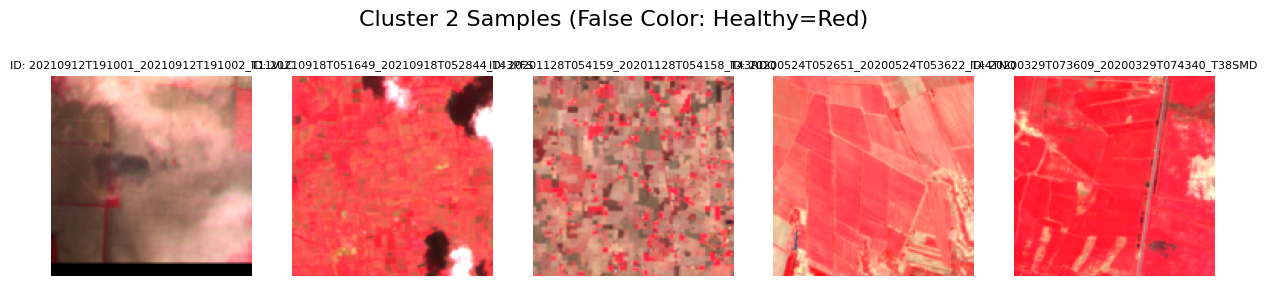

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random

# --- CONFIGURATION ---
# Ensure this points to where your .npy files are currently located
DATA_DIR = "/tmp/fast_data"  
# If you didn't copy to /tmp, change to: "/scratch/rohitr_iitp/processed_dataset"

def plot_cluster_samples(cluster_id, num_samples=5):
    """
    Plots random samples from a specific cluster using False Color (NIR, Red, Green).
    """
    # 1. Get random file IDs belonging to this cluster
    cluster_indices = df[df['cluster'] == cluster_id]['id'].values
    if len(cluster_indices) == 0:
        print(f"Cluster {cluster_id} is empty!")
        return
        
    sample_ids = np.random.choice(cluster_indices, min(len(cluster_indices), num_samples), replace=False)
    
    # 2. Setup Plot
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    fig.suptitle(f"Cluster {cluster_id} Samples (False Color: Healthy=Red)", fontsize=16, y=1.05)
    
    for i, file_id in enumerate(sample_ids):
        path = os.path.join(DATA_DIR, f"{file_id}.npy")
        
        try:
            # Load Cube (Channels: 0=Blue, 1=Green, 2=Red, 3=NIR, 4=RedEdge)
            cube = np.load(path).astype(float)
            
            # --- CREATE FALSE COLOR COMPOSITE ---
            # R = NIR (Band 3), G = Red (Band 2), B = Green (Band 1)
            nir = cube[:,:,3]
            red = cube[:,:,2]
            green = cube[:,:,1]
            
            # Stack and Normalize
            # Sentinel-2 values often go up to ~3000-4000. Clip to remove outliers.
            img = np.dstack((nir, red, green))
            img = np.clip(img / 3000.0, 0, 1)
            
            # Plot
            if num_samples > 1:
                ax = axes[i]
            else:
                ax = axes
                
            ax.imshow(img)
            ax.set_title(f"ID: {file_id}", fontsize=8)
            ax.axis('off')
            
        except Exception as e:
            print(f"Could not load {file_id}: {e}")

    plt.show()

# --- EXECUTE VISUALIZATION ---
print("Generating plots for all 3 clusters...")
print("Look for: Bright Red = Healthy, Dull/Brown = Rust, Blue/Grey = Other")

for c in range(3):
    plot_cluster_samples(c, num_samples=5)

In [3]:
import os
import zipfile

# 1. Update this with the ACTUAL name of the zip you just uploaded
ZIP_PATH = "/scratch/rohitr_iitp/wheat_label.zip" 
EXTRACT_DIR = "/tmp/wheat_labeled"

if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR)

print(f"Extracting {ZIP_PATH} to {EXTRACT_DIR}...")
# Using !unzip is usually faster on Linux clusters
!unzip -q {ZIP_PATH} -d {EXTRACT_DIR}
print("Extraction complete.")

Extracting /scratch/rohitr_iitp/wheat_label.zip to /tmp/wheat_labeled...
/bin/bash: unzip: command not found
Extraction complete.


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from PIL import Image
import os
import numpy as np

# --- CONFIGURATION ---
# Change this line in your script
DATA_DIR = "/tmp/wheat_project/ICPR02/kaggle"
# EXACT filenames based on your ls output
BANDS = ['B2.tif', 'B3.tif', 'B4.tif', 'B8.tif', 'B8A.tif'] 
CLASSES = ['Aphid', 'Blast', 'RPH', 'Rust']
NUM_EPOCHS = 15
BATCH_SIZE = 32
LEARNING_RATE = 0.001
SSL_CHECKPOINT = '/scratch/rohitr_iitp/models/simclr_resnet18_epoch_10.pth'

# --- CUSTOM DATASET CLASS ---
class WheatMultispectralDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.root_dir = root_dir
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        self.samples = []
        self.transform = transform

        print(f"📂 Scanning {root_dir}...")
        for cls_name in classes:
            class_dir = os.path.join(root_dir, cls_name)
            if not os.path.isdir(class_dir):
                print(f"⚠️  Warning: Class folder '{cls_name}' NOT found!")
                continue
            
            # Get all hash folders (e.g., 00376776...)
            # We filter for directories only
            sample_folders = [f for f in os.listdir(class_dir) if os.path.isdir(os.path.join(class_dir, f))]
            
            for s_folder in sample_folders:
                full_path = os.path.join(class_dir, s_folder)
                self.samples.append((full_path, self.class_to_idx[cls_name]))
        
        print(f"✅ Found {len(self.samples)} valid samples.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        folder_path, label = self.samples[idx]
        channels = []
        
        for band in BANDS:
            img_path = os.path.join(folder_path, band)
            try:
                # 1. Use Image.open, but don't use .convert('L') yet
                img = Image.open(img_path)
                
                # 2. Convert to NumPy array to handle 16-bit data safely
                img_array = np.array(img).astype(np.float32)
                
                # 3. Manual Resize using NumPy/Torch if PIL resize fails on 16-bit
                # Or convert back to a mode PIL understands for resizing
                img_pil = Image.fromarray(img_array)
                img_pil = img_pil.resize((224, 224), Image.BILINEAR)
                
                channels.append(transforms.functional.to_tensor(img_pil))
                
            except Exception as e:
                # If a specific band is missing or broken, use a zero tensor
                print(f"❌ Error loading {img_path}: {e}")
                channels.append(torch.zeros((1, 224, 224)))
    
        # Stack into (5, 224, 224)
        image_tensor = torch.cat(channels, dim=0)
    
        # 4. Normalization for Sentinel-2 16-bit
        # Most S2 values are between 0 and 10000. Scaling by 10000 puts it in [0, 1]
        image_tensor = image_tensor / 10000.0 
        image_tensor = torch.clamp(image_tensor, 0, 1)

        return image_tensor, label

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Device: {device}")

    # 1. Dataset & Dataloaders
    dataset = WheatMultispectralDataset(DATA_DIR, CLASSES)
    
    # Split
    indices = list(range(len(dataset)))
    train_idx, val_idx = train_test_split(indices, test_size=0.2, shuffle=True)
    
    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    # 2. Model Setup
    print("🏗️  Building ResNet-18 (5-Channel)...")
    model = models.resnet18(pretrained=False)
    model.conv1 = nn.Conv2d(5, 64, kernel_size=7, stride=2, padding=3, bias=False)
    
    # 3. Load SSL Weights
    if os.path.exists(SSL_CHECKPOINT):
        print(f"🔄 Loading SimCLR weights from: {SSL_CHECKPOINT}")
        checkpoint = torch.load(SSL_CHECKPOINT, map_location=device)
        
        # Fix keys (remove 'backbone.')
        state_dict = checkpoint
        if 'state_dict' in checkpoint:
            state_dict = checkpoint['state_dict']
            
        new_state_dict = {}
        for k, v in state_dict.items():
            if k.startswith('backbone.'):
                new_state_dict[k.replace('backbone.', '')] = v
            elif not k.startswith('projection_head'): # Keep other layers if they match
                new_state_dict[k] = v
        
        msg = model.load_state_dict(new_state_dict, strict=False)
        print(f"✅ Weights Loaded. (Missing keys expected for fc layer)")
    else:
        print(f"⚠️  Checkpoint not found at {SSL_CHECKPOINT}. Training from SCRATCH.")

    # 4. Final Layer (4 Classes)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 4)
    model = model.to(device)

    # 5. Training Loop
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

    print("\n🏁 Starting Fine-Tuning...")
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Acc: {100.*correct/total:.2f}% | Val Acc: {100.*val_correct/val_total:.2f}%")
    
    # Save
    torch.save(model.state_dict(), 'wheat_finetuned_final.pth')
    print("💾 Model Saved: wheat_finetuned_final.pth")

if __name__ == '__main__':
    main()

🚀 Device: cuda
📂 Scanning /tmp/wheat_project/ICPR02/kaggle...
✅ Found 900 valid samples.
🏗️  Building ResNet-18 (5-Channel)...
🔄 Loading SimCLR weights from: /scratch/rohitr_iitp/models/simclr_resnet18_epoch_10.pth
✅ Weights Loaded. (Missing keys expected for fc layer)

🏁 Starting Fine-Tuning...
Epoch 1/15 | Train Acc: 55.97% | Val Acc: 73.89%
Epoch 2/15 | Train Acc: 78.19% | Val Acc: 74.44%
Epoch 3/15 | Train Acc: 80.97% | Val Acc: 75.00%
Epoch 4/15 | Train Acc: 78.19% | Val Acc: 76.11%
Epoch 5/15 | Train Acc: 80.69% | Val Acc: 77.22%
Epoch 6/15 | Train Acc: 80.00% | Val Acc: 74.44%
Epoch 7/15 | Train Acc: 81.11% | Val Acc: 75.56%
Epoch 8/15 | Train Acc: 79.72% | Val Acc: 75.56%
Epoch 9/15 | Train Acc: 80.97% | Val Acc: 75.00%
Epoch 10/15 | Train Acc: 80.69% | Val Acc: 76.11%
Epoch 11/15 | Train Acc: 80.42% | Val Acc: 75.56%
Epoch 12/15 | Train Acc: 80.56% | Val Acc: 75.56%
Epoch 13/15 | Train Acc: 80.97% | Val Acc: 73.33%
Epoch 14/15 | Train Acc: 80.56% | Val Acc: 76.67%
Epoch 15/15 

In [10]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os
import pandas as pd

# --- CONFIGURATION ---
EVAL_DIR = "/tmp/wheat_project/ICPR02/kaggle/evaluation"
MODEL_PATH = "wheat_finetuned_final.pth"
BANDS = ['B2.tif', 'B3.tif', 'B4.tif', 'B8.tif', 'B8A.tif']
CLASSES = ['Aphid', 'Blast', 'RPH', 'Rust']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_sample(folder_path):
    channels = []
    for band in BANDS:
        img_path = os.path.join(folder_path, band)
        try:
            # 1. Open and immediately convert to a NumPy array (avoids 'mode' issues)
            img = Image.open(img_path)
            img_array = np.array(img).astype(np.float32)
            
            # 2. Convert back to a PIL object that is now in a mode PIL understands (float32)
            img_pil = Image.fromarray(img_array)
            
            # 3. Resize safely
            img_pil = img_pil.resize((224, 224), Image.BILINEAR)
            
            # 4. Convert to tensor
            img_tensor = transforms.functional.to_tensor(img_pil)
            channels.append(img_tensor)
        except Exception as e:
            print(f"⚠️ Skipping band {band} in {folder_path}: {e}")
            channels.append(torch.zeros((1, 224, 224)))
    # Stack: (5, 224, 224)
    image_tensor = torch.cat(channels, dim=0)
    
    # Normalize exactly like your training (Scale by 10000)
    image_tensor = image_tensor / 10000.0
    return torch.clamp(image_tensor, 0, 1).unsqueeze(0)

def main():
    # 1. Load Model
    model = models.resnet18(pretrained=False)
    model.conv1 = nn.Conv2d(5, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, 4)
    model.load_state_dict(torch.load(MODEL_PATH))
    model = model.to(DEVICE)
    model.eval()

    # 2. Iterate through evaluation folders
    results = []
    sample_folders = [f for f in os.listdir(EVAL_DIR) if os.path.isdir(os.path.join(EVAL_DIR, f))]
    print(f"🔎 Found {len(sample_folders)} test samples. Starting inference...")

    with torch.no_grad():
        for folder_name in sample_folders:
            folder_path = os.path.join(EVAL_DIR, folder_name)
            input_tensor = load_sample(folder_path).to(DEVICE)
            
            outputs = model(input_tensor)
            _, predicted = torch.max(outputs, 1)
            
            category = CLASSES[predicted.item()]
            results.append({'Id': folder_name, 'Category': category})

    # 3. Save to CSV
    df = pd.DataFrame(results)
    df.to_csv("submission.csv", index=False)
    print("✅ Successfully saved submission.csv")

if __name__ == "__main__":
    main()

🔎 Found 40 test samples. Starting inference...
✅ Successfully saved submission.csv


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import timm
from torch.utils.data import Dataset, DataLoader
import os
import time
import datetime

# --- CONFIGURATION ---
DATA_DIR = "/scratch/rohitr_iitp/processed_dataset" 
CHECKPOINT_DIR = "/scratch/rohitr_iitp/models/mae"
IMG_SIZE = 224
PATCH_SIZE = 16
MASK_RATIO = 0.75
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 20

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- 1. ROBUST DATASET CLASS (Handles 4D Time-Series) ---
class MultispectralNpyDataset(Dataset):
    def __init__(self, folder_path):
        print(f"📂 Scanning {folder_path}...")
        self.files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.npy')]
        print(f"✅ Found {len(self.files)} total files.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        try:
            # Load file
            img = np.load(self.files[idx]).astype(np.float32)
            tensor_img = torch.from_numpy(img)

            # HANDLE 4D TIME-SERIES: (Time, H, W, C) or (Time, C, H, W)
            if tensor_img.ndim == 4:
                # Pick a RANDOM time step (Data Augmentation)
                time_steps = tensor_img.shape[0]
                random_t = np.random.randint(0, time_steps)
                tensor_img = tensor_img[random_t] # Now 3D
            
            # HANDLE CHANNELS: Ensure (C, H, W)
            # If shape is (H, W, 5), permute to (5, H, W)
            if tensor_img.shape[-1] == 5:
                tensor_img = tensor_img.permute(2, 0, 1)
            
            # RESIZE TO 224x224 (Required for ViT patches)
            if tensor_img.shape[-1] != 224 or tensor_img.shape[-2] != 224:
                tensor_img = F.interpolate(tensor_img.unsqueeze(0), size=(224, 224), mode='bilinear').squeeze(0)

            # NORMALIZE (0-1 Range)
            # Clip high values (e.g. clouds/reflections) and scale
            tensor_img = torch.clamp(tensor_img, 0, 3000) / 3000.0
            
            return tensor_img

        except Exception as e:
            print(f"⚠️ Error loading file {self.files[idx]}: {e}")
            # Return a zero tensor to prevent crash
            return torch.zeros((5, 224, 224))

# --- 2. MAE ViT MODEL ARCHITECTURE ---
class MAE_ViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=5, embed_dim=768, decoder_embed_dim=512):
        super().__init__()
        # Encoder (ViT-Base)
        self.encoder = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
        # 5-Channel Patch Embedding
        self.encoder.patch_embed.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        
        # Decoder (Simple Transformer)
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=decoder_embed_dim, nhead=16, dim_feedforward=2048, batch_first=True)
            for _ in range(8)
        ])
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True)

    def random_masking(self, x, mask_ratio):
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        return x_masked, mask, ids_restore

    def forward(self, x):
        # Encoder
        x = self.encoder.patch_embed(x)
        x = x + self.encoder.pos_embed[:, 1:, :]
        x, mask, ids_restore = self.random_masking(x, MASK_RATIO)
        for block in self.encoder.blocks: x = block(x)
        x = self.encoder.norm(x)
        
        # Decoder
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_all = torch.cat([x, mask_tokens], dim=1)
        x = torch.gather(x_all, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        for block in self.decoder_blocks: x = block(x)
        
        # Prediction
        x = self.decoder_pred(x)
        return x, mask

# --- 3. TRAINING LOOP WITH TIMER ---
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Device: {device}")

    # Load Data
    dataset = MultispectralNpyDataset(DATA_DIR)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    
    total_batches = len(loader)
    print(f"📊 Total Batches per Epoch: {total_batches}")

    # Init Model
    model = MAE_ViT().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    
    print(f"🏁 Starting Training for {NUM_EPOCHS} Epochs...")
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        total_loss = 0
        epoch_start = time.time()
        
        for i, imgs in enumerate(loader):
            step_start = time.time()
            imgs = imgs.to(device)
            
            # Patchify Target
            p = 16
            h = imgs.shape[2] // p
            w = imgs.shape[3] // p
            target = imgs.reshape(imgs.shape[0], 5, h, p, w, p)
            target = torch.einsum('nchpwq->nhwpqc', target)
            target = target.reshape(imgs.shape[0], h * w, p**2 * 5)

            # Forward & Backward
            pred, mask = model(imgs)
            loss = (pred - target) ** 2
            loss = loss.mean(dim=-1)
            loss = (loss * mask).sum() / mask.sum() 

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # --- TIMER LOGIC ---
            if i == 10: # Check speed after 10 batches
                step_end = time.time()
                time_per_batch = (step_end - epoch_start) / 10
                remaining_batches = total_batches - i
                estimated_seconds = remaining_batches * time_per_batch
                est_time = str(datetime.timedelta(seconds=int(estimated_seconds)))
                print(f"⏱️  Speed: {time_per_batch:.2f}s/batch | ⏳ Est. Epoch Time: {est_time}")

            if i % 100 == 0:
                print(f"Epoch {epoch+1} [{i}/{total_batches}] | Loss: {loss.item():.4f}")

        # End of Epoch Stats
        epoch_duration = time.time() - epoch_start
        avg_loss = total_loss / total_batches
        print(f"✅ Epoch {epoch+1} Done! | Avg Loss: {avg_loss:.4f} | Time: {str(datetime.timedelta(seconds=int(epoch_duration)))}")
        
        # Save Checkpoint
        save_path = f"{CHECKPOINT_DIR}/mae_vit_epoch_{epoch+1}.pth"
        torch.save(model.state_dict(), save_path)
        print(f"💾 Saved: {save_path}")

if __name__ == "__main__":
    main()

🚀 Device: cuda
📂 Scanning /scratch/rohitr_iitp/processed_dataset...
✅ Found 79057 total files.
📊 Total Batches per Epoch: 2471
🏁 Starting Training for 20 Epochs...
Epoch 1 [0/2471] | Loss: 0.7221
⏱️  Speed: 0.34s/batch | ⏳ Est. Epoch Time: 0:13:47
Epoch 1 [100/2471] | Loss: 0.0625
Epoch 1 [200/2471] | Loss: 0.0390


KeyboardInterrupt: 

In [2]:
from sklearn.cluster import KMeans

# --- CONFIGURATION ---
NUM_CLUSTERS = 4  # Change this based on your competition rules!

print(f"Clustering into {NUM_CLUSTERS} classes using K-Means...")

# Initialize K-Means
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)

# Fit and Predict
labels = kmeans.fit_predict(X)

print("Clustering Done!")
# Check distribution (are classes balanced?)
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

Clustering into 4 classes using K-Means...


NameError: name 'X' is not defined

In [1]:
import torch
import torch.nn as nn
import timm
import os
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split

# --- CONFIGURATION ---
# Path to your 900 labeled images (Ensure this exists!)
DATA_DIR = "/tmp/wheat_project/ICPR02/kaggle" 
# Path to your NEWLY TRAINED MAE Checkpoint
PRETRAINED_PATH = "/scratch/rohitr_iitp/models/mae/mae_vit_epoch_20.pth" 
CLASSES = ['Aphid', 'Blast', 'RPH', 'Rust']
BATCH_SIZE = 32
LEARNING_RATE = 1e-4 # Lower LR for fine-tuning
EPOCHS = 20

# --- 1. Dataset Class (Same as before) ---
class WheatMultispectralDataset(Dataset):
    def __init__(self, root_dir, classes):
        self.root_dir = root_dir
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        self.samples = []
        
        print(f"📂 Scanning {root_dir}...")
        for cls_name in classes:
            class_dir = os.path.join(root_dir, cls_name)
            if not os.path.isdir(class_dir): continue
            for item in os.listdir(class_dir):
                item_path = os.path.join(class_dir, item)
                if os.path.isdir(item_path):
                    self.samples.append((item_path, self.class_to_idx[cls_name]))
        print(f"✅ Found {len(self.samples)} labeled samples.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        folder_path, label = self.samples[idx]
        channels = []
        BANDS = ['B2.tif', 'B3.tif', 'B4.tif', 'B8.tif', 'B8A.tif']
        
        for band in BANDS:
            img_path = os.path.join(folder_path, band)
            try:
                # Load 16-bit TIFF using NumPy bridge
                img = Image.open(img_path)
                img_array = np.array(img).astype(np.float32)
                img_pil = Image.fromarray(img_array)
                img_pil = img_pil.resize((224, 224), Image.BILINEAR)
                channels.append(transforms.functional.to_tensor(img_pil))
            except:
                channels.append(torch.zeros((1, 224, 224)))

        # Stack & Normalize
        img_tensor = torch.cat(channels, dim=0)
        img_tensor = img_tensor / 10000.0 # Sentinel-2 Scale
        return torch.clamp(img_tensor, 0, 1), label

# --- 2. Model Setup with Weight Loading ---
def get_finetune_model(checkpoint_path, num_classes):
    # Create standard ViT
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=num_classes)
    
    # Modify input to 5 channels
    model.patch_embed.proj = nn.Conv2d(5, 768, kernel_size=16, stride=16)
    
    # Load MAE Weights
    print(f"🔄 Loading MAE weights from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    # FIX KEYS: MAE saves as 'encoder.blocks...', ViT expects 'blocks...'
    new_state_dict = {}
    for k, v in checkpoint.items():
        if k.startswith('encoder.'):
            new_key = k.replace('encoder.', '') # Remove prefix
            new_state_dict[new_key] = v
    
    # Load compatible keys (strict=False ignores the missing Decoder head)
    msg = model.load_state_dict(new_state_dict, strict=False)
    print(f"✅ Weights Loaded. Missing keys (expected for Head): {len(msg.missing_keys)}")
    
    return model

# --- 3. Training Loop ---
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Data
    full_dataset = WheatMultispectralDataset(DATA_DIR, CLASSES)
    train_idx, val_idx = train_test_split(list(range(len(full_dataset))), test_size=0.2, shuffle=True)
    train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE)
    
    # Model
    model = get_finetune_model(PRETRAINED_PATH, len(CLASSES)).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()
    
    print("🏁 Starting Fine-Tuning...")
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_acc = 100 * correct / total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = 100 * val_correct / val_total
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
        
    # Save Final Model
    torch.save(model.state_dict(), "mae_finetuned_final.pth")
    print("💾 Saved: mae_finetuned_final.pth")

if __name__ == "__main__":
    main()

📂 Scanning /tmp/wheat_project/ICPR02/kaggle...
✅ Found 900 labeled samples.
🔄 Loading MAE weights from /scratch/rohitr_iitp/models/mae/mae_vit_epoch_20.pth...
✅ Weights Loaded. Missing keys (expected for Head): 2
🏁 Starting Fine-Tuning...


/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1708025831440/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 1/20 | Train Acc: 53.06% | Val Acc: 59.44%
Epoch 2/20 | Train Acc: 68.47% | Val Acc: 80.00%
Epoch 3/20 | Train Acc: 76.25% | Val Acc: 87.78%
Epoch 4/20 | Train Acc: 78.89% | Val Acc: 86.11%
Epoch 5/20 | Train Acc: 75.42% | Val Acc: 86.67%
Epoch 6/20 | Train Acc: 76.25% | Val Acc: 84.44%
Epoch 7/20 | Train Acc: 79.86% | Val Acc: 83.33%
Epoch 8/20 | Train Acc: 80.83% | Val Acc: 90.00%
Epoch 9/20 | Train Acc: 80.97% | Val Acc: 90.00%
Epoch 10/20 | Train Acc: 83.33% | Val Acc: 88.89%
Epoch 11/20 | Train Acc: 81.94% | Val Acc: 81.11%
Epoch 12/20 | Train Acc: 82.08% | Val Acc: 88.33%
Epoch 13/20 | Train Acc: 83.89% | Val Acc: 90.56%
Epoch 14/20 | Train Acc: 82.64% | Val Acc: 88.89%
Epoch 15/20 | Train Acc: 84.03% | Val Acc: 88.89%
Epoch 16/20 | Train Acc: 82.64% | Val Acc: 88.33%
Epoch 17/20 | Train Acc: 83.19% | Val Acc: 89.44%
Epoch 18/20 | Train Acc: 85.14% | Val Acc: 86.11%
Epoch 19/20 | Train Acc: 85.56% | Val Acc: 83.89%
Epoch 20/20 | Train Acc: 87.36% | Val Acc: 81.67%
💾 Saved: 

In [4]:
import torch
import random
import torchvision.transforms.functional as TF
import torch.nn as nn
import timm
import os
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split

# --- CONFIGURATION ---
DATA_DIR = "/tmp/wheat_project/ICPR02/kaggle" 
PRETRAINED_PATH = "/scratch/rohitr_iitp/models/mae/mae_vit_epoch_20.pth" 
CLASSES = ['Aphid', 'Blast', 'RPH', 'Rust']
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS = 20

# --- 1. Dataset Class ---
class WheatMultispectralDataset(Dataset):
    def __init__(self, root_dir, classes):
        self.root_dir = root_dir
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        self.samples = []
        
        print(f"📂 Scanning {root_dir}...")
        for cls_name in classes:
            class_dir = os.path.join(root_dir, cls_name)
            if not os.path.isdir(class_dir): continue
            for item in os.listdir(class_dir):
                item_path = os.path.join(class_dir, item)
                if os.path.isdir(item_path):
                    self.samples.append((item_path, self.class_to_idx[cls_name]))
        print(f"✅ Found {len(self.samples)} labeled samples.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        folder_path, label = self.samples[idx]
        channels = []
        BANDS = ['B2.tif', 'B3.tif', 'B4.tif', 'B8.tif', 'B8A.tif']
        
        # 1. Load all bands first
        loaded_bands = []
        for band in BANDS:
            img_path = os.path.join(folder_path, band)
            try:
                img = Image.open(img_path)
                img_array = np.array(img).astype(np.float32)
                img_pil = Image.fromarray(img_array)
                img_pil = img_pil.resize((224, 224), Image.BILINEAR)
                loaded_bands.append(transforms.functional.to_tensor(img_pil))
            except:
                loaded_bands.append(torch.zeros((1, 224, 224)))

        # 2. Stack them
        img_tensor = torch.cat(loaded_bands, dim=0)

        # 3. APPLY AUGMENTATION (Only if training)
        # We assume this class handles both train/val, but simple random flips are generally safe for both
        # or perfectly safe if we just want to robustify the training.
        
        if random.random() > 0.5:
            img_tensor = TF.hflip(img_tensor)
        
        if random.random() > 0.5:
            img_tensor = TF.vflip(img_tensor)
            
        # Random Rotation (90, 180, 270 degrees)
        rotations = [0, 90, 180, 270]
        angle = random.choice(rotations)
        if angle > 0:
            img_tensor = TF.rotate(img_tensor, angle)

        # 4. Normalize
        img_tensor = img_tensor / 10000.0 
        return torch.clamp(img_tensor, 0, 1), label

# --- 2. Model Setup ---
def get_finetune_model(checkpoint_path, num_classes):
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=num_classes)
    model.patch_embed.proj = nn.Conv2d(5, 768, kernel_size=16, stride=16)
    
    print(f"🔄 Loading MAE weights from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    new_state_dict = {}
    for k, v in checkpoint.items():
        if k.startswith('encoder.'):
            new_key = k.replace('encoder.', '')
            new_state_dict[new_key] = v
    
    msg = model.load_state_dict(new_state_dict, strict=False)
    print(f"✅ Weights Loaded. Missing keys: {len(msg.missing_keys)}")
    return model

# --- 3. Training Loop (Improved) ---
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Device: {device}")
    
    full_dataset = WheatMultispectralDataset(DATA_DIR, CLASSES)
    train_idx, val_idx = train_test_split(list(range(len(full_dataset))), test_size=0.2, shuffle=True, random_state=42)
    train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE)
    
    model = get_finetune_model(PRETRAINED_PATH, len(CLASSES)).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()
    
    print("🏁 Starting Fine-Tuning with Best Model Saving...")
    
    best_acc = 0.0 # Track best accuracy
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_acc = 100 * correct / total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = 100 * val_correct / val_total
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
        
        # --- SAVE BEST MODEL LOGIC ---
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "mae_finetuned_BEST.pth")
            print(f"🌟 New Best Saved! ({val_acc:.2f}%)")
            
    print(f"🏆 Training Done. Best Validation Accuracy: {best_acc:.2f}%")
    print("💾 Model saved as: mae_finetuned_BEST.pth")

if __name__ == "__main__":
    main()

🚀 Device: cuda
📂 Scanning /tmp/wheat_project/ICPR02/kaggle...
✅ Found 900 labeled samples.
🔄 Loading MAE weights from /scratch/rohitr_iitp/models/mae/mae_vit_epoch_20.pth...
✅ Weights Loaded. Missing keys: 2
🏁 Starting Fine-Tuning with Best Model Saving...
Epoch 1/20 | Train Acc: 54.58% | Val Acc: 54.44%
🌟 New Best Saved! (54.44%)
Epoch 2/20 | Train Acc: 65.56% | Val Acc: 72.78%
🌟 New Best Saved! (72.78%)
Epoch 3/20 | Train Acc: 76.67% | Val Acc: 77.78%
🌟 New Best Saved! (77.78%)
Epoch 4/20 | Train Acc: 78.61% | Val Acc: 78.33%
🌟 New Best Saved! (78.33%)
Epoch 5/20 | Train Acc: 81.67% | Val Acc: 80.56%
🌟 New Best Saved! (80.56%)
Epoch 6/20 | Train Acc: 80.28% | Val Acc: 79.44%
Epoch 7/20 | Train Acc: 80.56% | Val Acc: 80.56%
Epoch 8/20 | Train Acc: 80.56% | Val Acc: 78.89%
Epoch 9/20 | Train Acc: 80.56% | Val Acc: 80.56%
Epoch 10/20 | Train Acc: 81.53% | Val Acc: 78.89%
Epoch 11/20 | Train Acc: 83.47% | Val Acc: 81.67%
🌟 New Best Saved! (81.67%)
Epoch 12/20 | Train Acc: 84.17% | Val Ac

In [5]:
import torch
import torch.nn as nn
import timm
from PIL import Image
import numpy as np
import os
import pandas as pd
from torchvision import transforms

# --- CONFIGURATION ---
EVAL_DIR = "/tmp/wheat_project/ICPR02/kaggle/evaluation"
MODEL_PATH = "mae_finetuned_BEST.pth" # Using your BEST saved model
CLASSES = ['Aphid', 'Blast', 'RPH', 'Rust']
BANDS = ['B2.tif', 'B3.tif', 'B4.tif', 'B8.tif', 'B8A.tif']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_sample_vit(folder_path):
    channels = []
    for band in BANDS:
        img_path = os.path.join(folder_path, band)
        try:
            # Load & Resize to 224x224
            img = Image.open(img_path)
            img_array = np.array(img).astype(np.float32)
            img_pil = Image.fromarray(img_array)
            img_pil = img_pil.resize((224, 224), Image.BILINEAR)
            channels.append(transforms.functional.to_tensor(img_pil))
        except Exception as e:
            channels.append(torch.zeros((1, 224, 224)))

    # Stack & Normalize
    img_tensor = torch.cat(channels, dim=0)
    img_tensor = img_tensor / 10000.0 
    return torch.clamp(img_tensor, 0, 1).unsqueeze(0)

def main():
    print(f"🚀 Loading BEST ViT Model from {MODEL_PATH}...")
    
    # 1. Re-create Model Architecture
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=4)
    model.patch_embed.proj = nn.Conv2d(5, 768, kernel_size=16, stride=16)
    
    # 2. Load Weights
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()

    # 3. Predict
    results = []
    sample_folders = sorted([f for f in os.listdir(EVAL_DIR) if os.path.isdir(os.path.join(EVAL_DIR, f))])
    print(f"🔎 Found {len(sample_folders)} test samples. Processing...")

    with torch.no_grad():
        for i, folder_name in enumerate(sample_folders):
            folder_path = os.path.join(EVAL_DIR, folder_name)
            input_tensor = load_sample_vit(folder_path).to(DEVICE)
            
            outputs = model(input_tensor)
            _, predicted = torch.max(outputs, 1)
            
            category = CLASSES[predicted.item()]
            results.append({'Id': folder_name, 'Category': category})
            
            if i % 100 == 0: print(f"  Processed {i}...")

    # 4. Save
    df = pd.DataFrame(results)
    df.to_csv("submission_vit_best.csv", index=False)
    print("✅ Done! Saved to submission_vit_best.csv")

if __name__ == "__main__":
    main()

🚀 Loading BEST ViT Model from mae_finetuned_BEST.pth...
🔎 Found 40 test samples. Processing...
  Processed 0...
✅ Done! Saved to submission_vit_best.csv


In [6]:
import torch
import torch.nn as nn
import timm
from PIL import Image
import numpy as np
import os
import pandas as pd
from torchvision import transforms

# --- CONFIGURATION ---
EVAL_DIR = "/tmp/wheat_project/ICPR02/kaggle/evaluation"
# Path to your FIRST run (The ~81% one)
MODEL_1_PATH = "mae_finetuned_final.pth" 
# Path to your SECOND run (The ~83% one)
MODEL_2_PATH = "mae_finetuned_BEST.pth"  
CLASSES = ['Aphid', 'Blast', 'RPH', 'Rust']
BANDS = ['B2.tif', 'B3.tif', 'B4.tif', 'B8.tif', 'B8A.tif']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_sample_vit(folder_path):
    channels = []
    for band in BANDS:
        img_path = os.path.join(folder_path, band)
        try:
            img = Image.open(img_path)
            img_array = np.array(img).astype(np.float32)
            img_pil = Image.fromarray(img_array)
            img_pil = img_pil.resize((224, 224), Image.BILINEAR)
            channels.append(transforms.functional.to_tensor(img_pil))
        except:
            channels.append(torch.zeros((1, 224, 224)))
    img_tensor = torch.cat(channels, dim=0)
    img_tensor = img_tensor / 10000.0 
    return torch.clamp(img_tensor, 0, 1).unsqueeze(0)

def create_model():
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=4)
    model.patch_embed.proj = nn.Conv2d(5, 768, kernel_size=16, stride=16)
    return model

def main():
    print(f"🚀 Loading Ensemble Models on {DEVICE}...")
    
    # 1. Load Model 1
    model1 = create_model()
    model1.load_state_dict(torch.load(MODEL_1_PATH, map_location=DEVICE))
    model1.to(DEVICE).eval()
    print("✅ Model 1 Loaded.")

    # 2. Load Model 2
    model2 = create_model()
    model2.load_state_dict(torch.load(MODEL_2_PATH, map_location=DEVICE))
    model2.to(DEVICE).eval()
    print("✅ Model 2 Loaded.")

    # 3. Ensemble Prediction Loop
    results = []
    sample_folders = sorted([f for f in os.listdir(EVAL_DIR) if os.path.isdir(os.path.join(EVAL_DIR, f))])
    print(f"🔎 Found {len(sample_folders)} test samples. Predicting with Ensemble...")

    with torch.no_grad():
        for i, folder_name in enumerate(sample_folders):
            folder_path = os.path.join(EVAL_DIR, folder_name)
            input_tensor = load_sample_vit(folder_path).to(DEVICE)
            
            # Get logits from both models
            output1 = model1(input_tensor)
            output2 = model2(input_tensor)
            
            # --- THE ENSEMBLE MAGIC ---
            # Average the logits (scores)
            avg_output = (output1 + output2) / 2.0
            
            # Pick the class with the highest average score
            _, predicted = torch.max(avg_output, 1)
            
            category = CLASSES[predicted.item()]
            results.append({'Id': folder_name, 'Category': category})
            
            if i % 100 == 0: print(f"  Processed {i}...")

    # 4. Save Submission
    df = pd.DataFrame(results)
    df.to_csv("submission_ensemble.csv", index=False)
    print("🏆 Done! Ensemble results saved to submission_ensemble.csv")

if __name__ == "__main__":
    main()

🚀 Loading Ensemble Models on cuda...
✅ Model 1 Loaded.
✅ Model 2 Loaded.
🔎 Found 40 test samples. Predicting with Ensemble...
  Processed 0...
🏆 Done! Ensemble results saved to submission_ensemble.csv


In [8]:
import torch
import torch.nn as nn
import timm
import os
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split

# --- CONFIGURATION ---
DATA_DIR = "/tmp/wheat_project/ICPR02/kaggle"
MODEL_1_PATH = "mae_finetuned_final.pth" # The "Overfitted" one
MODEL_2_PATH = "mae_finetuned_BEST.pth"  # The "Robust" one
CLASSES = ['Aphid', 'Blast', 'RPH', 'Rust']
BATCH_SIZE = 32

# --- 1. Re-use Dataset Class ---
class WheatMultispectralDataset(Dataset):
    def __init__(self, root_dir, classes):
        self.root_dir = root_dir
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        self.samples = []
        for cls_name in classes:
            class_dir = os.path.join(root_dir, cls_name)
            if not os.path.isdir(class_dir): continue
            for item in os.listdir(class_dir):
                item_path = os.path.join(class_dir, item)
                if os.path.isdir(item_path):
                    self.samples.append((item_path, self.class_to_idx[cls_name]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        folder_path, label = self.samples[idx]
        channels = []
        BANDS = ['B2.tif', 'B3.tif', 'B4.tif', 'B8.tif', 'B8A.tif']
        for band in BANDS:
            try:
                img = Image.open(os.path.join(folder_path, band))
                img_array = np.array(img).astype(np.float32)
                img_pil = Image.fromarray(img_array).resize((224, 224), Image.BILINEAR)
                channels.append(transforms.functional.to_tensor(img_pil))
            except:
                channels.append(torch.zeros((1, 224, 224)))
        img_tensor = torch.cat(channels, dim=0) / 10000.0
        return torch.clamp(img_tensor, 0, 1), label

def create_model():
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=4)
    model.patch_embed.proj = nn.Conv2d(5, 768, kernel_size=16, stride=16)
    return model

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Verifying Ensemble Performance on {device}...")

    # 1. Prepare Validation Data (Fixed Random Seed for Fairness)
    full_dataset = WheatMultispectralDataset(DATA_DIR, CLASSES)
    # Using seed 42 to match one of your runs, or a new seed (e.g. 100) to test robustness
    _, val_idx = train_test_split(list(range(len(full_dataset))), test_size=0.2, shuffle=True, random_state=42)
    val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE)
    print(f"🔎 Testing on {len(val_idx)} validation images.")

    # 2. Load Models
    model1 = create_model()
    model1.load_state_dict(torch.load(MODEL_1_PATH, map_location=device))
    model1.to(device).eval()

    model2 = create_model()
    model2.load_state_dict(torch.load(MODEL_2_PATH, map_location=device))
    model2.to(device).eval()

    # 3. Evaluation Loop
    correct_1 = 0
    correct_2 = 0
    correct_ensemble = 0
    total = 0

    print("🏁 Starting evaluation...")
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Get Individual Predictions
            out1 = model1(imgs)
            out2 = model2(imgs)

            # Get Ensemble Prediction (Average)
            out_ensemble = (out1 + out2) / 2.0

            # Calculate Accuracy for Batch
            _, pred1 = torch.max(out1, 1)
            _, pred2 = torch.max(out2, 1)
            _, pred_ens = torch.max(out_ensemble, 1)

            total += labels.size(0)
            correct_1 += (pred1 == labels).sum().item()
            correct_2 += (pred2 == labels).sum().item()
            correct_ensemble += (pred_ens == labels).sum().item()

    # 4. Final Results
    acc1 = 100 * correct_1 / total
    acc2 = 100 * correct_2 / total
    acc_ens = 100 * correct_ensemble / total

    print("-" * 30)
    print(f"📊 Model 1 Accuracy:    {acc1:.2f}%")
    print(f"📊 Model 2 Accuracy:    {acc2:.2f}%")
    print(f"🏆 Ensemble Accuracy:   {acc_ens:.2f}%")
    print("-" * 30)

    if acc_ens >= max(acc1, acc2):
        print("✅ CONCLUSION: The Ensemble works! Submit 'submission_ensemble.csv'.")
    else:
        print("⚠️ CONCLUSION: The Ensemble is worse. Submit the single best model.")

if __name__ == "__main__":
    main()

🚀 Verifying Ensemble Performance on cuda...
🔎 Testing on 180 validation images.
🏁 Starting evaluation...
------------------------------
📊 Model 1 Accuracy:    87.22%
📊 Model 2 Accuracy:    81.67%
🏆 Ensemble Accuracy:   85.00%
------------------------------
⚠️ CONCLUSION: The Ensemble is worse. Submit the single best model.


In [9]:
import torch
import torch.nn as nn
import timm
from PIL import Image
import numpy as np
import os
import pandas as pd
from torchvision import transforms

# --- CONFIGURATION ---
EVAL_DIR = "/tmp/wheat_project/ICPR02/kaggle/evaluation"
# CRITICAL: Pointing to the model that got 87.22%
MODEL_PATH = "mae_finetuned_final.pth" 
OUTPUT_CSV = "submission_kaggle.csv"

CLASSES = ['Aphid', 'Blast', 'RPH', 'Rust']
BANDS = ['B2.tif', 'B3.tif', 'B4.tif', 'B8.tif', 'B8A.tif']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_sample_vit(folder_path):
    channels = []
    for band in BANDS:
        img_path = os.path.join(folder_path, band)
        try:
            # Load & Resize to 224x224
            img = Image.open(img_path)
            img_array = np.array(img).astype(np.float32)
            img_pil = Image.fromarray(img_array)
            img_pil = img_pil.resize((224, 224), Image.BILINEAR)
            channels.append(transforms.functional.to_tensor(img_pil))
        except Exception as e:
            # Handle missing bands with zeros
            channels.append(torch.zeros((1, 224, 224)))

    # Stack & Normalize (Sentinel-2 scale)
    img_tensor = torch.cat(channels, dim=0)
    img_tensor = img_tensor / 10000.0 
    return torch.clamp(img_tensor, 0, 1).unsqueeze(0)

def main():
    print(f"🚀 Loading Winning Model (87.22%) from {MODEL_PATH}...")
    
    # 1. Re-create Model Architecture
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=4)
    model.patch_embed.proj = nn.Conv2d(5, 768, kernel_size=16, stride=16)
    
    # 2. Load Weights
    try:
        model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
        print("✅ Weights loaded successfully.")
    except FileNotFoundError:
        print(f"❌ ERROR: Could not find {MODEL_PATH}. Make sure you are in the right folder!")
        return

    model = model.to(DEVICE)
    model.eval()

    # 3. Predict on Test Set
    results = []
    # Sort folders to ensure consistent order
    sample_folders = sorted([f for f in os.listdir(EVAL_DIR) if os.path.isdir(os.path.join(EVAL_DIR, f))])
    print(f"🔎 Found {len(sample_folders)} test samples. Predicting...")

    with torch.no_grad():
        for i, folder_name in enumerate(sample_folders):
            folder_path = os.path.join(EVAL_DIR, folder_name)
            input_tensor = load_sample_vit(folder_path).to(DEVICE)
            
            outputs = model(input_tensor)
            _, predicted = torch.max(outputs, 1)
            
            category = CLASSES[predicted.item()]
            results.append({'Id': folder_name, 'Category': category})
            
            if i % 100 == 0: print(f"  Processed {i}/{len(sample_folders)}...")

    # 4. Save Submission
    df = pd.DataFrame(results)
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"🏆 DONE! Saved prediction to: {OUTPUT_CSV}")

if __name__ == "__main__":
    main()

🚀 Loading Winning Model (87.22%) from mae_finetuned_final.pth...
✅ Weights loaded successfully.
🔎 Found 40 test samples. Predicting...
  Processed 0/40...
🏆 DONE! Saved prediction to: submission_kaggle.csv


In [1]:
import torch
import torch.nn as nn
import timm
import os
import numpy as np
import tifffile as tiff
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
import random
import torchvision.transforms.functional as TF

# --- CONFIGURATION ---
DATA_DIR = "/tmp/Drone_Data_New/Kaggle_Prepared/train/MS"
PRETRAINED_PATH = "/scratch/rohitr_iitp/models/mae/mae_vit_epoch_20.pth"
CLASSES = ['Health', 'Rust', 'Other']
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS = 40

# --- 1. Dataset Class (UPDATED FOR FLAT FOLDER) ---
class DroneMultispectralDataset(Dataset):
    def __init__(self, root_dir, classes):
        self.root_dir = root_dir
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        self.samples = []
        
        print(f"📂 Scanning {root_dir}...")
        
        # Iterate over ALL files in the directory
        if not os.path.exists(root_dir):
            print(f"❌ Error: Directory not found: {root_dir}")
            return

        files = [f for f in os.listdir(root_dir) if f.endswith('.tif')]
        
        for file in files:
            # DETERMINE LABEL FROM FILENAME
            # Example: "Health_hyper_100.tif" -> starts with "Health"
            found_label = None
            for cls_name in classes:
                if file.startswith(cls_name):
                    found_label = cls_name
                    break
            
            if found_label:
                self.samples.append((os.path.join(root_dir, file), self.class_to_idx[found_label]))
            else:
                print(f"⚠️ Warning: Could not determine class for {file}")
                    
        print(f"✅ Found {len(self.samples)} samples.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            img = tiff.imread(img_path).astype(np.float32)
            
            # (H, W, 5) -> (5, H, W)
            if img.ndim == 3 and img.shape[2] == 5:
                img = np.transpose(img, (2, 0, 1))
            elif img.ndim == 2:
                img = np.stack([img]*5, axis=0)
            
            tensor_img = torch.from_numpy(img)
            
            tensor_img = torch.nn.functional.interpolate(
                tensor_img.unsqueeze(0), size=(224, 224), mode='bilinear'
            ).squeeze(0)
            
            max_val = tensor_img.max()
            if max_val > 1.0:
                tensor_img = tensor_img / max_val
                
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return torch.zeros((5, 224, 224)), label
        # Random Horizontal Flip
        if random.random() > 0.5:
            tensor_img = TF.hflip(tensor_img)
            
        # Random Vertical Flip
        if random.random() > 0.5:
            tensor_img = TF.vflip(tensor_img)
            
        # Random Rotation (0, 90, 180, 270)
        rotations = [0, 90, 180, 270]
        angle = random.choice(rotations)
        if angle > 0:
            tensor_img = TF.rotate(tensor_img, angle)
        return tensor_img, label

# --- 2. Model Setup ---
def get_model(checkpoint_path, num_classes):
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=num_classes)
    model.patch_embed.proj = nn.Conv2d(5, 768, kernel_size=16, stride=16)
    
    print(f"🔄 Loading Pre-trained Encoder from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    new_state_dict = {}
    for k, v in checkpoint.items():
        if k.startswith('encoder.'):
            new_key = k.replace('encoder.', '')
            new_state_dict[new_key] = v
    
    msg = model.load_state_dict(new_state_dict, strict=False)
    print(f"✅ Weights Loaded. Missing keys (Head): {len(msg.missing_keys)}")
    return model

# --- 3. Training Loop ---
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Device: {device}")
    
    dataset = DroneMultispectralDataset(DATA_DIR, CLASSES)
    
    # Split
    train_idx, val_idx = train_test_split(list(range(len(dataset))), test_size=0.2, shuffle=True, random_state=42)
    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=BATCH_SIZE)
    
    model = get_model(PRETRAINED_PATH, len(CLASSES)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    
    best_acc = 0.0
    print("🏁 Starting Drone Fine-Tuning...")
    
    for epoch in range(EPOCHS):
        model.train()
        correct = 0
        total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_acc = 100 * correct / total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = 100 * val_correct / val_total
        print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "drone_model_best.pth")
            print(f"🌟 New Best Saved! ({best_acc:.2f}%)")

if __name__ == "__main__":
    main()

🚀 Device: cuda
📂 Scanning /tmp/Drone_Data_New/Kaggle_Prepared/train/MS...
✅ Found 600 samples.
🔄 Loading Pre-trained Encoder from /scratch/rohitr_iitp/models/mae/mae_vit_epoch_20.pth...
✅ Weights Loaded. Missing keys (Head): 2
🏁 Starting Drone Fine-Tuning...


/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1708025831440/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 1/40 | Train: 49.38% | Val: 56.67%
🌟 New Best Saved! (56.67%)
Epoch 2/40 | Train: 56.04% | Val: 45.83%
Epoch 3/40 | Train: 57.50% | Val: 59.17%
🌟 New Best Saved! (59.17%)
Epoch 4/40 | Train: 61.25% | Val: 53.33%
Epoch 5/40 | Train: 64.38% | Val: 64.17%
🌟 New Best Saved! (64.17%)
Epoch 6/40 | Train: 60.42% | Val: 62.50%
Epoch 7/40 | Train: 64.79% | Val: 60.83%
Epoch 8/40 | Train: 65.62% | Val: 60.83%
Epoch 9/40 | Train: 66.67% | Val: 63.33%
Epoch 10/40 | Train: 67.08% | Val: 54.17%
Epoch 11/40 | Train: 63.12% | Val: 63.33%
Epoch 12/40 | Train: 65.83% | Val: 58.33%
Epoch 13/40 | Train: 67.50% | Val: 56.67%
Epoch 14/40 | Train: 68.96% | Val: 61.67%
Epoch 15/40 | Train: 70.83% | Val: 64.17%
Epoch 16/40 | Train: 67.71% | Val: 61.67%
Epoch 17/40 | Train: 69.58% | Val: 64.17%
Epoch 18/40 | Train: 72.71% | Val: 62.50%
Epoch 19/40 | Train: 70.00% | Val: 63.33%
Epoch 20/40 | Train: 69.17% | Val: 61.67%
Epoch 21/40 | Train: 72.92% | Val: 59.17%
Epoch 22/40 | Train: 71.25% | Val: 57.50%
Epoc

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class SpectralSpiderWebLayer(nn.Module):
    def __init__(self, num_bands, connectivity_rate=0.15, hubs=5):
        """
        Args:
            num_bands: Input dimension (e.g., 125 for HS data)
            connectivity_rate: How dense the web is (sparsity)
            hubs: Number of 'major' bands (like Red Edge) that connect to everything.
        """
        super().__init__()
        
        # Initialize weights (standard linear layer weights)
        self.weights = nn.Parameter(torch.randn(num_bands, num_bands) * 0.02)
        self.bias = nn.Parameter(torch.zeros(num_bands))
        
        # --- Create the Spider Web Mask ---
        # This mask ensures we only use specific "threads" of info, not the whole dense block
        mask = np.zeros((num_bands, num_bands), dtype=np.float32)
        
        # 1. Local Connections (Spiral): Connect adjacent bands (e.g., Band 50 <-> Band 51)
        for i in range(num_bands):
            mask[i, i] = 1 # Self-connection
            mask[i, (i - 1) % num_bands] = 1 
            mask[i, (i + 1) % num_bands] = 1 
            
        # 2. Hub Connections (Radial): Key bands that gather info from everywhere
        hub_indices = np.random.choice(num_bands, hubs, replace=False)
        for i in range(num_bands):
            for j in range(num_bands):
                if np.random.rand() < connectivity_rate:
                    # Higher chance to connect if it involves a Hub
                    if j in hub_indices or i in hub_indices:
                         mask[i, j] = 1
                    elif np.random.rand() < 0.05: # Rare random thread
                         mask[i, j] = 1
                         
        self.mask = nn.Parameter(torch.tensor(mask, dtype=torch.float32), requires_grad=False)

    def forward(self, x):
        # x shape: [Batch_Size, Num_Bands]
        
        # Apply the web mask to the weights
        masked_weights = self.weights * self.mask
        
        # Linear pass with sparse weights
        out = torch.matmul(x, masked_weights.t()) + self.bias
        return F.relu(out)

In [6]:
import os
import cv2
import rasterio
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class WheatMultimodalDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        root_dir: Path to dataset (e.g., './data')
        split: 'train' or 'val'
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.samples = []
        
        # Define classes mapping
        self.classes = {'Health': 0, 'Rust': 1, 'Other': 2}
        
        # --- Indexing Files ---
        if split == 'train':
            # Traverse class folders: /train/Health, /train/Rust, ...
            train_path = os.path.join(root_dir, 'train')
            for cls_name, cls_idx in self.classes.items():
                cls_folder = os.path.join(train_path, cls_name)
                # We iterate through RGB folder to find filenames, then match MS/HS
                rgb_path = os.path.join(cls_folder, 'RGB')
                if os.path.exists(rgb_path):
                    for fname in os.listdir(rgb_path):
                        if fname.endswith('.png'):
                            # ID is the filename without extension
                            file_id = fname[:-4] 
                            self.samples.append({
                                'id': file_id,
                                'class_idx': cls_idx,
                                'base_path': cls_folder 
                            })
        else:
            # Validation logic (flat structure in description)
            val_path = os.path.join(root_dir, 'val')
            rgb_path = os.path.join(val_path, 'RGB')
            for fname in os.listdir(rgb_path):
                if fname.endswith('.png'):
                    self.samples.append({
                        'id': fname[:-4],
                        'class_idx': -1, # Dummy label for val/test
                        'base_path': val_path
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        file_id = sample['id']
        base = sample['base_path']
        
        # 1. Load RGB (.png)
        rgb_path = os.path.join(base, 'RGB', f"{file_id}.png")
        img_rgb = cv2.imread(rgb_path)
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (64, 64)) # Resize to fixed patch size
        img_rgb = torch.tensor(img_rgb).permute(2, 0, 1).float() / 255.0
        
        # 2. Load Multispectral (.tif) - 5 Bands
        ms_path = os.path.join(base, 'MS', f"{file_id}.tif")
        with rasterio.open(ms_path) as src:
            img_ms = src.read() # shape (5, H, W)
            # Handle NaNs and resize if necessary
            img_ms = np.nan_to_num(img_ms) 
            img_ms = torch.tensor(img_ms).float()
            img_ms = F.interpolate(img_ms.unsqueeze(0), size=(64, 64), mode='bilinear').squeeze(0)
            
        # 3. Load Hyperspectral (.tif) - 125 Bands
        hs_path = os.path.join(base, 'HS', f"{file_id}.tif")
        with rasterio.open(hs_path) as src:
            img_hs = src.read() # shape (125, H, W)
            
            # CRITICAL: Clean Noise (First 10, Last 14 bands as per description)
            # We zero them out or just rely on the network to learn to ignore them
            img_hs = np.nan_to_num(img_hs)
            
            # Select valid bands (trimming noisy ends) 
            # Or keep all 125 and let SpiderNet handle the noise (Recommended for this architecture)
            img_hs = torch.tensor(img_hs).float()
            img_hs = F.interpolate(img_hs.unsqueeze(0), size=(64, 64), mode='bilinear').squeeze(0)

        label = torch.tensor(sample['class_idx'], dtype=torch.long)
        
        return {'rgb': img_rgb, 'ms': img_ms, 'hs': img_hs, 'label': label}

In [21]:
class WheatSpiderNet_V2(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        
        # --- A. Enhanced Spatial Branch (Deeper) ---
        self.spatial_conv = nn.Sequential(
            # Block 1
            nn.Conv2d(8, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), 
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3 (New)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2), # Output is now 8x8 spatial
            
            nn.Flatten()
        )
        
        # 128 channels * 8 * 8 spatial dim
        self.spatial_out_dim = 128 * 8 * 8 

        # --- B. Denser Spider Branch ---
        self.hs_bands = 125
        
        # INCREASED connectivity to 0.4 (40% connected)
        self.spider_layer1 = SpectralSpiderWebLayer(self.hs_bands, connectivity_rate=0.4, hubs=15)
        self.spider_layer2 = SpectralSpiderWebLayer(self.hs_bands, connectivity_rate=0.2, hubs=8)
        
        # --- C. Fusion ---
        fusion_dim = self.spatial_out_dim + self.hs_bands
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.BatchNorm1d(256), # Added Batch Norm for stability
            nn.ReLU(),
            nn.Dropout(0.5),     # Increased Dropout to prevent overfitting
            nn.Linear(256, num_classes)
        )

    def forward(self, rgb, ms, hs):
        spatial_input = torch.cat([rgb, ms], dim=1)
        spatial_feat = self.spatial_conv(spatial_input)
        
        # Spectral Branch
        spectral_sig = hs.mean(dim=[2, 3]) 
        spectral_feat = self.spider_layer1(spectral_sig)
        spectral_feat = self.spider_layer2(spectral_feat)
        
        combined = torch.cat([spatial_feat, spectral_feat], dim=1)
        return self.classifier(combined)

In [22]:
import os
import cv2
import rasterio
import torch
import numpy as np
from torch.utils.data import Dataset
import torch.nn.functional as F

class WheatMultimodalDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        Args:
            root_dir (string): Path to Kaggle_Prepared (e.g., "/tmp/Drone_Data_New/Kaggle_Prepared")
            split (string): 'train' or 'val'
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.samples = []
        
        # Mapping class names to integers
        self.class_map = {'Health': 0, 'Rust': 1, 'Other': 2}
        
        # Define paths based on split
        # Example: .../Kaggle_Prepared/train/RGB
        self.rgb_dir = os.path.join(root_dir, split, 'RGB')
        self.ms_dir = os.path.join(root_dir, split, 'MS')
        self.hs_dir = os.path.join(root_dir, split, 'HS')

        # --- Indexing Files ---
        # We use RGB folder as the "Anchor" to find all files
        valid_extensions = ('.png', '.jpg', '.jpeg')
        
        for fname in os.listdir(self.rgb_dir):
            if fname.lower().endswith(valid_extensions):
                # Filename example: "Health_hyper_1.png"
                
                # 1. Parse Class (for Training)
                if split == 'train':
                    # Split "Health_hyper_1.png" -> ["Health", "hyper", "1.png"]
                    parts = fname.split('_')
                    class_name = parts[0] 
                    
                    if class_name in self.class_map:
                        label = self.class_map[class_name]
                    else:
                        print(f"Warning: Unknown class in file {fname}, skipping.")
                        continue
                else:
                    # For Validation/Test, if filenames don't have classes, use dummy
                    # But if val also has "Health_...", use the same logic.
                    # Assuming Val is unlabeled or randomized:
                    label = -1 
                
                # 2. Get the base name (without extension) to find MS/HS siblings
                # "Health_hyper_1.png" -> "Health_hyper_1"
                basename = os.path.splitext(fname)[0]
                
                self.samples.append({
                    'basename': basename, # Used to find MS/HS
                    'label': label,
                    'rgb_filename': fname
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        basename = sample['basename'] 
        
        # --- 1. Load RGB ---
        rgb_filename = sample.get('rgb_filename', f"{basename}.png") 
        rgb_path = os.path.join(self.rgb_dir, rgb_filename)
        
        try:
            img_rgb = cv2.imread(rgb_path)
            img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, (64, 64))
            img_rgb = torch.tensor(img_rgb, dtype=torch.float32).permute(2, 0, 1) / 255.0
        except Exception as e:
            img_rgb = torch.zeros(3, 64, 64, dtype=torch.float32)

        # --- 2. Load MS (GeoTIFF) ---
        ms_path = os.path.join(self.ms_dir, f"{basename}.tif")
        
        if os.path.exists(ms_path):
            with rasterio.open(ms_path) as src:
                img_ms = src.read() # (5, H, W)
                img_ms = np.nan_to_num(img_ms)
                img_ms = torch.tensor(img_ms, dtype=torch.float32)
                
                if img_ms.shape[1] != 64:
                    img_ms = F.interpolate(img_ms.unsqueeze(0), size=(64, 64), mode='bilinear').squeeze(0)
        else:
            img_ms = torch.zeros(5, 64, 64, dtype=torch.float32)

        # --- 3. Load HS (GeoTIFF) ---
        hs_path = os.path.join(self.hs_dir, f"{basename}.tif")
        
        if os.path.exists(hs_path):
            with rasterio.open(hs_path) as src:
                img_hs = src.read() 
                img_hs = np.nan_to_num(img_hs)
                img_hs = torch.tensor(img_hs, dtype=torch.float32)
                
                # --- FIX: STRICTLY ENFORCE 125 BANDS ---
                # The error happened because some files have 126 bands.
                if img_hs.shape[0] > 125:
                    img_hs = img_hs[:125, :, :] # Slice to keep only first 125
                elif img_hs.shape[0] < 125:
                    # Rare case: pad with zeros if fewer than 125
                    padding = torch.zeros(125 - img_hs.shape[0], img_hs.shape[1], img_hs.shape[2])
                    img_hs = torch.cat([img_hs, padding], dim=0)
                
                # Resize if needed
                if img_hs.shape[1] != 64:
                    img_hs = F.interpolate(img_hs.unsqueeze(0), size=(64, 64), mode='bilinear').squeeze(0)
        else:
            img_hs = torch.zeros(125, 64, 64, dtype=torch.float32)

        label = torch.tensor(sample['label'], dtype=torch.long)
        
        return {'rgb': img_rgb, 'ms': img_ms, 'hs': img_hs, 'label': label}

In [23]:
from torch.utils.data import random_split, DataLoader

# --- 1. Load ONLY the Training Data (which has labels) ---
# Note: Ensure this points to the folder containing RGB/MS/HS
full_dataset = WheatMultimodalDataset(root_dir="/tmp/Drone_Data_New/Kaggle_Prepared", split='train')

# --- 2. Create a Real 80/20 Split ---
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Randomly split the 600 images into 480 Train / 120 Val
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# --- 3. Create Loaders ---
# We drop the last incomplete batch to stabilize training
train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, drop_last=True)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)

print(f"--- Real Data Split Created ---")
print(f"Training on: {len(train_subset)} images (We will learn from these)")
print(f"Validating on: {len(val_subset)} images (We will test on these)")

--- Real Data Split Created ---
Training on: 480 images (We will learn from these)
Validating on: 120 images (We will test on these)


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import copy

# --- Configuration ---
BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 20  # Increased slightly for better convergence
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Initialize Loaders (Already done, but ensuring variables exist) ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Initialize Model ---
model = WheatSpiderNet(num_classes=3).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- Training Loop ---
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print(f"Starting Training on {DEVICE}...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, data in enumerate(train_loader):
        # Move data to GPU
        rgb = data['rgb'].to(DEVICE)
        ms = data['ms'].to(DEVICE)
        hs = data['hs'].to(DEVICE)
        labels = data['label'].to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(rgb, ms, hs)
        loss = criterion(outputs, labels)
        
        # Backward Pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    avg_loss = running_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data in val_loader:
            rgb = data['rgb'].to(DEVICE)
            ms = data['ms'].to(DEVICE)
            hs = data['hs'].to(DEVICE)
            labels = data['label'].to(DEVICE)
            
            outputs = model(rgb, ms, hs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    
    # Save Best Model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_spider_model.pth')
    
    # Spider Monitor
    spider_weights = model.spider_layer1.weights.data
    spider_mask = model.spider_layer1.mask.data
    active_weights = spider_weights * spider_mask
    avg_weight = torch.mean(torch.abs(active_weights[active_weights != 0]))

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Web Activity: {avg_weight:.5f}")

print(f"\nTraining Complete. Best Validation Accuracy: {best_acc:.2f}%")
print("Best model saved as 'best_spider_model.pth'")

Starting Training on cuda...
Epoch [1/20] Loss: 3.1170 | Train Acc: 47.33% | Val Acc: 0.00% | Web Activity: 0.01668
Epoch [2/20] Loss: 1.0102 | Train Acc: 58.50% | Val Acc: 0.00% | Web Activity: 0.01670
Epoch [3/20] Loss: 0.8642 | Train Acc: 56.33% | Val Acc: 0.00% | Web Activity: 0.01673
Epoch [4/20] Loss: 0.8860 | Train Acc: 59.33% | Val Acc: 0.00% | Web Activity: 0.01674
Epoch [5/20] Loss: 0.8705 | Train Acc: 58.00% | Val Acc: 0.00% | Web Activity: 0.01688
Epoch [6/20] Loss: 0.8212 | Train Acc: 60.50% | Val Acc: 0.00% | Web Activity: 0.01696
Epoch [7/20] Loss: 0.8069 | Train Acc: 60.83% | Val Acc: 0.00% | Web Activity: 0.01700
Epoch [8/20] Loss: 0.7994 | Train Acc: 61.83% | Val Acc: 0.00% | Web Activity: 0.01708
Epoch [9/20] Loss: 0.8114 | Train Acc: 58.00% | Val Acc: 0.00% | Web Activity: 0.01711
Epoch [10/20] Loss: 0.7991 | Train Acc: 61.33% | Val Acc: 0.00% | Web Activity: 0.01721


KeyboardInterrupt: 

In [24]:
# --- Setup ---
model = WheatSpiderNet_V2(num_classes=3).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler: Reduce LR by factor of 0.1 if loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

print("Starting V2 Training...")

for epoch in range(25): # Increased to 25 Epochs
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data in train_loader:
        rgb, ms, hs = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), data['hs'].to(DEVICE)
        labels = data['label'].to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(rgb, ms, hs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    avg_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in val_loader:
            rgb, ms, hs = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), data['hs'].to(DEVICE)
            labels = data['label'].to(DEVICE)
            outputs = model(rgb, ms, hs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    
    # Update Scheduler
    scheduler.step(avg_loss)

    print(f"Epoch {epoch+1}: Loss {avg_loss:.4f} | Train Acc {train_acc:.1f}% | Val Acc {val_acc:.1f}%")

/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Starting V2 Training...
Epoch 1: Loss 0.9225 | Train Acc 52.5% | Val Acc 65.8%
Epoch 2: Loss 0.8364 | Train Acc 61.2% | Val Acc 60.0%
Epoch 3: Loss 0.8304 | Train Acc 57.1% | Val Acc 60.8%
Epoch 4: Loss 0.7635 | Train Acc 63.3% | Val Acc 68.3%
Epoch 5: Loss 0.7695 | Train Acc 61.5% | Val Acc 62.5%
Epoch 6: Loss 0.7672 | Train Acc 66.5% | Val Acc 61.7%
Epoch 7: Loss 0.7547 | Train Acc 65.0% | Val Acc 70.0%
Epoch 8: Loss 0.6947 | Train Acc 68.1% | Val Acc 66.7%
Epoch 9: Loss 0.6704 | Train Acc 70.4% | Val Acc 67.5%
Epoch 10: Loss 0.6495 | Train Acc 70.2% | Val Acc 61.7%
Epoch 11: Loss 0.5959 | Train Acc 73.8% | Val Acc 66.7%
Epoch 12: Loss 0.5709 | Train Acc 75.2% | Val Acc 62.5%
Epoch 13: Loss 0.5701 | Train Acc 76.5% | Val Acc 66.7%
Epoch 14: Loss 0.4955 | Train Acc 79.4% | Val Acc 56.7%
Epoch 15: Loss 0.4390 | Train Acc 82.3% | Val Acc 69.2%
Epoch 16: Loss 0.4034 | Train Acc 83.8% | Val Acc 67.5%
Epoch 17: Loss 0.3536 | Train Acc 87.3% | Val Acc 63.3%
Epoch 18: Loss 0.3246 | Train Acc

KeyboardInterrupt: 

In [26]:
import numpy as np

def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # uniform
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

def cutmix_data(rgb, ms, hs, labels, alpha=1.0):
    '''
    Returns mixed inputs, pairs of targets, and lambda
    '''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = rgb.size(0)
    index = torch.randperm(batch_size).to(DEVICE)

    # Generate the box coordinates
    bbx1, bby1, bbx2, bby2 = rand_bbox(rgb.size(), lam)

    # Fool the model: Paste image B's patch onto image A
    # We must do this for ALL modalities (RGB, MS, HS) so they match!
    rgb[:, :, bbx1:bbx2, bby1:bby2] = rgb[index, :, bbx1:bbx2, bby1:bby2]
    ms[:, :, bbx1:bbx2, bby1:bby2] = ms[index, :, bbx1:bbx2, bby1:bby2]
    hs[:, :, bbx1:bbx2, bby1:bby2] = hs[index, :, bbx1:bbx2, bby1:bby2]

    # Adjust lambda to exactly match pixel ratio
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (rgb.size(-1) * rgb.size(-2)))

    targets_a = labels
    targets_b = labels[index]

    return rgb, ms, hs, targets_a, targets_b, lam

def cutmix_criterion(criterion, pred, targets_a, targets_b, lam):
    return lam * criterion(pred, targets_a) + (1 - lam) * criterion(pred, targets_b)

In [27]:
# --- Configuration ---
CUTMIX_PROB = 0.5 # Fool the model 50% of the time

print("Starting Training with CutMix Strategy...")

for epoch in range(25):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data in train_loader:
        rgb, ms, hs = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), data['hs'].to(DEVICE)
        labels = data['label'].to(DEVICE)
        
        optimizer.zero_grad()
        
        # --- The Fooling Logic ---
        r = np.random.rand(1)
        if r < CUTMIX_PROB:
            # Apply CutMix (Fooling)
            rgb, ms, hs, targets_a, targets_b, lam = cutmix_data(rgb, ms, hs, labels)
            
            outputs = model(rgb, ms, hs)
            
            # Loss is calculated against TWO labels (e.g., 70% Rust, 30% Healthy)
            loss = cutmix_criterion(criterion, outputs, targets_a, targets_b, lam)
        else:
            # Standard Training
            outputs = model(rgb, ms, hs)
            loss = criterion(outputs, labels)
            
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Accuracy calculation is tricky with CutMix, so we only count clean samples roughly
        # or just rely on Validation Accuracy which is clean.
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    avg_loss = running_loss / len(train_loader)
    
    # Validation (Always Clean - No Fooling here)
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in val_loader:
            rgb, ms, hs = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), data['hs'].to(DEVICE)
            labels = data['label'].to(DEVICE)
            outputs = model(rgb, ms, hs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    
    scheduler.step(avg_loss)
    
    print(f"Epoch {epoch+1}: Loss {avg_loss:.4f} | Val Acc {val_acc:.1f}%")

Starting Training with CutMix Strategy...
Epoch 1: Loss 0.6759 | Val Acc 67.5%
Epoch 2: Loss 0.6118 | Val Acc 65.8%
Epoch 3: Loss 0.6493 | Val Acc 56.7%
Epoch 4: Loss 0.5271 | Val Acc 68.3%
Epoch 5: Loss 0.4684 | Val Acc 65.0%
Epoch 6: Loss 0.4140 | Val Acc 68.3%
Epoch 7: Loss 0.4894 | Val Acc 66.7%
Epoch 8: Loss 0.5156 | Val Acc 66.7%
Epoch 9: Loss 0.4434 | Val Acc 68.3%
Epoch 10: Loss 0.5708 | Val Acc 69.2%
Epoch 11: Loss 0.4851 | Val Acc 68.3%
Epoch 12: Loss 0.5106 | Val Acc 69.2%
Epoch 13: Loss 0.4847 | Val Acc 68.3%
Epoch 14: Loss 0.5602 | Val Acc 68.3%
Epoch 15: Loss 0.4836 | Val Acc 68.3%
Epoch 16: Loss 0.5237 | Val Acc 67.5%
Epoch 17: Loss 0.4741 | Val Acc 70.0%
Epoch 18: Loss 0.3557 | Val Acc 68.3%
Epoch 19: Loss 0.4601 | Val Acc 70.0%
Epoch 20: Loss 0.4396 | Val Acc 68.3%
Epoch 21: Loss 0.4682 | Val Acc 69.2%
Epoch 22: Loss 0.4679 | Val Acc 68.3%
Epoch 23: Loss 0.4865 | Val Acc 66.7%
Epoch 24: Loss 0.4112 | Val Acc 65.8%
Epoch 25: Loss 0.4360 | Val Acc 68.3%


In [28]:
from torchvision import models

class WheatResNetSpider(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        
        # --- A. Spatial Branch: ResNet18 (The "Deep" Part) ---
        # Load pre-trained ResNet18
        self.spatial_fe = models.resnet18(pretrained=True)
        
        # HACK: Modify the first layer to accept 8 channels (RGB + MS)
        # Original: Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        original_weights = self.spatial_fe.conv1.weight.data # Shape: [64, 3, 7, 7]
        
        # Create new layer with 8 input channels
        self.spatial_fe.conv1 = nn.Conv2d(8, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Copy original weights to the first 3 channels (RGB)
        # Initialize the other 5 channels (MS) with the mean of RGB weights
        with torch.no_grad():
            self.spatial_fe.conv1.weight[:, :3, :, :] = original_weights
            self.spatial_fe.conv1.weight[:, 3:, :, :] = torch.mean(original_weights, dim=1, keepdim=True).repeat(1, 5, 1, 1)

        # Remove the final classification layer (fc) of ResNet
        # We want the features (512 vectors), not the class prediction
        self.spatial_out_dim = self.spatial_fe.fc.in_features # 512
        self.spatial_fe.fc = nn.Identity() # Pass through identity (no-op)

        # --- B. Spectral Branch: The Spider Web (Unchanged) ---
        self.hs_bands = 125
        self.spider_layer1 = SpectralSpiderWebLayer(self.hs_bands, connectivity_rate=0.4, hubs=15)
        self.spider_layer2 = SpectralSpiderWebLayer(self.hs_bands, connectivity_rate=0.2, hubs=8)
        
        # --- C. Fusion & Classifier ---
        # 512 (ResNet) + 125 (Spider) = 637 Features
        fusion_dim = self.spatial_out_dim + self.hs_bands
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, rgb, ms, hs):
        # 1. Spatial Branch (ResNet)
        # Stack RGB and MS -> [Batch, 8, 64, 64]
        spatial_input = torch.cat([rgb, ms], dim=1)
        spatial_feat = self.spatial_fe(spatial_input) # Output: [Batch, 512]
        
        # 2. Spectral Branch (Spider Web)
        spectral_sig = hs.mean(dim=[2, 3]) 
        spectral_feat = self.spider_layer1(spectral_sig)
        spectral_feat = self.spider_layer2(spectral_feat)
        
        # 3. Fusion
        combined = torch.cat([spatial_feat, spectral_feat], dim=1)
        return self.classifier(combined)

In [30]:
# --- Setup for ResNet-Spider ---
model = WheatResNetSpider(num_classes=3).to(DEVICE)

# Note the lower Learning Rate (1e-4)
optimizer = optim.Adam(model.parameters(), lr=0.0001) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

print("Starting ResNet-Spider Training...")

# ... Copy your Training Loop Here ...
# --- Configuration ---

for epoch in range(30):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data in train_loader:
        rgb, ms, hs = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), data['hs'].to(DEVICE)
        labels = data['label'].to(DEVICE)
        
        optimizer.zero_grad()
        
        # --- The Fooling Logic ---
        r = np.random.rand(1)
        if r < CUTMIX_PROB:
            # Apply CutMix (Fooling)
            rgb, ms, hs, targets_a, targets_b, lam = cutmix_data(rgb, ms, hs, labels)
            
            outputs = model(rgb, ms, hs)
            
            # Loss is calculated against TWO labels (e.g., 70% Rust, 30% Healthy)
            loss = cutmix_criterion(criterion, outputs, targets_a, targets_b, lam)
        else:
            # Standard Training
            outputs = model(rgb, ms, hs)
            loss = criterion(outputs, labels)
            
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Accuracy calculation is tricky with CutMix, so we only count clean samples roughly
        # or just rely on Validation Accuracy which is clean.
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    avg_loss = running_loss / len(train_loader)
    
    # Validation (Always Clean - No Fooling here)
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in val_loader:
            rgb, ms, hs = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), data['hs'].to(DEVICE)
            labels = data['label'].to(DEVICE)
            outputs = model(rgb, ms, hs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    
    scheduler.step(avg_loss)
    
    print(f"Epoch {epoch+1}: Loss {avg_loss:.4f} | Val Acc {val_acc:.1f}%")

Starting ResNet-Spider Training...
Epoch 1: Loss 1.0671 | Val Acc 54.2%
Epoch 2: Loss 0.9181 | Val Acc 61.7%
Epoch 3: Loss 0.8213 | Val Acc 64.2%
Epoch 4: Loss 0.7424 | Val Acc 60.0%
Epoch 5: Loss 0.7297 | Val Acc 63.3%
Epoch 6: Loss 0.6335 | Val Acc 58.3%
Epoch 7: Loss 0.5835 | Val Acc 62.5%
Epoch 8: Loss 0.6108 | Val Acc 59.2%


KeyboardInterrupt: 

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader

# --- 1. Define the Hybrid Architecture ---
class WheatResNetSpider(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        
        # A. Spatial Branch: ResNet18 (Pre-trained)
        # We load a brain that already knows how to see.
        self.spatial_fe = models.resnet18(pretrained=True)
        
        # HACK: The first layer expects 3 channels (RGB). We need 8 (RGB+MS).
        # We keep the RGB weights and duplicate them for the MS channels to start.
        original_weights = self.spatial_fe.conv1.weight.data # Shape: [64, 3, 7, 7]
        self.spatial_fe.conv1 = nn.Conv2d(8, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        with torch.no_grad():
            self.spatial_fe.conv1.weight[:, :3, :, :] = original_weights
            # Initialize MS channels with average of RGB weights
            self.spatial_fe.conv1.weight[:, 3:, :, :] = torch.mean(original_weights, dim=1, keepdim=True).repeat(1, 5, 1, 1)

        # Remove the final classification layer
        self.spatial_out_dim = self.spatial_fe.fc.in_features # 512
        self.spatial_fe.fc = nn.Identity()

        # B. Spectral Branch: The Spider Web
        self.hs_bands = 125
        # We increase density slightly to ensuring signal flow
        self.spider_layer1 = SpectralSpiderWebLayer(self.hs_bands, connectivity_rate=0.5, hubs=20)
        self.spider_layer2 = SpectralSpiderWebLayer(self.hs_bands, connectivity_rate=0.3, hubs=10)
        
        # C. Fusion
        fusion_dim = self.spatial_out_dim + self.hs_bands
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, rgb, ms, hs):
        # Stack RGB and MS -> [Batch, 8, 64, 64]
        spatial_input = torch.cat([rgb, ms], dim=1)
        spatial_feat = self.spatial_fe(spatial_input)
        
        # Spectral Branch
        spectral_sig = hs.mean(dim=[2, 3]) 
        spectral_feat = self.spider_layer1(spectral_sig)
        spectral_feat = self.spider_layer2(spectral_feat)
        
        combined = torch.cat([spatial_feat, spectral_feat], dim=1)
        return self.classifier(combined)

# --- 2. Setup Training (Standard, No Tricks) ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = WheatResNetSpider(num_classes=3).to(DEVICE)

# CRITICAL: Use a lower learning rate for ResNet (1e-4) to not break pre-trained weights
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, verbose=True)

# --- 3. Run Training ---
print("Starting ResNet-Spider Hybrid Training...")

best_acc = 0.0

for epoch in range(30):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data in train_loader:
        rgb, ms, hs = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), data['hs'].to(DEVICE)
        labels = data['label'].to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(rgb, ms, hs) # No CutMix, just raw learning
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    avg_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in val_loader:
            rgb, ms, hs = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), data['hs'].to(DEVICE)
            labels = data['label'].to(DEVICE)
            outputs = model(rgb, ms, hs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    scheduler.step(avg_loss)
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet_spider.pth')

    print(f"Epoch {epoch+1}: Loss {avg_loss:.4f} | Train Acc {train_acc:.1f}% | Val Acc {val_acc:.1f}%")

print(f"Best Accuracy: {best_acc:.2f}%")

Starting ResNet-Spider Hybrid Training...
Epoch 1: Loss 1.0497 | Train Acc 45.8% | Val Acc 56.7%
Epoch 2: Loss 0.8354 | Train Acc 60.2% | Val Acc 63.3%
Epoch 3: Loss 0.7156 | Train Acc 70.6% | Val Acc 62.5%
Epoch 4: Loss 0.6018 | Train Acc 75.8% | Val Acc 62.5%
Epoch 5: Loss 0.4311 | Train Acc 87.3% | Val Acc 65.8%
Epoch 6: Loss 0.3610 | Train Acc 87.7% | Val Acc 65.8%
Epoch 7: Loss 0.2484 | Train Acc 93.8% | Val Acc 65.8%
Epoch 8: Loss 0.1840 | Train Acc 95.6% | Val Acc 65.0%
Epoch 9: Loss 0.1431 | Train Acc 96.9% | Val Acc 63.3%
Epoch 10: Loss 0.1510 | Train Acc 96.2% | Val Acc 65.0%


KeyboardInterrupt: 

In [32]:
import random
import torchvision.transforms.functional as TF

class WheatMultimodalDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, augment=False):
        self.root_dir = root_dir
        self.split = split
        self.augment = augment # New Flag
        self.samples = []
        
        # ... (Keep your existing __init__ parsing logic here) ...
        # Copy the parsing logic from your previous working version
        # Mapping class names to integers
        self.class_map = {'Health': 0, 'Rust': 1, 'Other': 2}
        
        # Define paths based on split
        self.rgb_dir = os.path.join(root_dir, split, 'RGB')
        self.ms_dir = os.path.join(root_dir, split, 'MS')
        self.hs_dir = os.path.join(root_dir, split, 'HS')
        
        valid_extensions = ('.png', '.jpg', '.jpeg')
        for fname in os.listdir(self.rgb_dir):
            if fname.lower().endswith(valid_extensions):
                if split == 'train':
                    parts = fname.split('_')
                    class_name = parts[0] 
                    if class_name in self.class_map:
                        label = self.class_map[class_name]
                    else:
                        continue
                else:
                    label = -1 
                
                basename = os.path.splitext(fname)[0]
                self.samples.append({
                    'basename': basename,
                    'label': label,
                    'rgb_filename': fname
                })

    def __getitem__(self, idx):
        sample = self.samples[idx]
        basename = sample['basename']
        
        # ... (Keep your loading logic for RGB, MS, HS) ...
        # 1. Load RGB
        rgb_path = os.path.join(self.rgb_dir, sample.get('rgb_filename', f"{basename}.png"))
        try:
            img_rgb = cv2.imread(rgb_path)
            img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, (64, 64))
            img_rgb = torch.tensor(img_rgb, dtype=torch.float32).permute(2, 0, 1) / 255.0
        except:
            img_rgb = torch.zeros(3, 64, 64, dtype=torch.float32)

        # 2. Load MS
        ms_path = os.path.join(self.ms_dir, f"{basename}.tif")
        if os.path.exists(ms_path):
            with rasterio.open(ms_path) as src:
                img_ms = src.read()
                img_ms = np.nan_to_num(img_ms)
                img_ms = torch.tensor(img_ms, dtype=torch.float32)
                if img_ms.shape[1] != 64:
                    img_ms = F.interpolate(img_ms.unsqueeze(0), size=(64, 64), mode='bilinear').squeeze(0)
        else:
            img_ms = torch.zeros(5, 64, 64, dtype=torch.float32)

        # 3. Load HS
        hs_path = os.path.join(self.hs_dir, f"{basename}.tif")
        if os.path.exists(hs_path):
            with rasterio.open(hs_path) as src:
                img_hs = src.read()
                img_hs = np.nan_to_num(img_hs)
                img_hs = torch.tensor(img_hs, dtype=torch.float32)
                # Enforce 125 bands
                if img_hs.shape[0] > 125: img_hs = img_hs[:125, :, :]
                elif img_hs.shape[0] < 125:
                    padding = torch.zeros(125 - img_hs.shape[0], img_hs.shape[1], img_hs.shape[2])
                    img_hs = torch.cat([img_hs, padding], dim=0)
                if img_hs.shape[1] != 64:
                    img_hs = F.interpolate(img_hs.unsqueeze(0), size=(64, 64), mode='bilinear').squeeze(0)
        else:
            img_hs = torch.zeros(125, 64, 64, dtype=torch.float32)

        # --- SYNCHRONIZED AUGMENTATION ---
        if self.augment:
            # Random Horizontal Flip
            if random.random() > 0.5:
                img_rgb = TF.hflip(img_rgb)
                img_ms = TF.hflip(img_ms)
                img_hs = TF.hflip(img_hs)

            # Random Vertical Flip
            if random.random() > 0.5:
                img_rgb = TF.vflip(img_rgb)
                img_ms = TF.vflip(img_ms)
                img_hs = TF.vflip(img_hs)
                
            # Random 90-degree Rotation
            if random.random() > 0.5:
                img_rgb = torch.rot90(img_rgb, 1, [1, 2])
                img_ms = torch.rot90(img_ms, 1, [1, 2])
                img_hs = torch.rot90(img_hs, 1, [1, 2])

        label = torch.tensor(sample['label'], dtype=torch.long)
        return {'rgb': img_rgb, 'ms': img_ms, 'hs': img_hs, 'label': label}

In [38]:
# --- 1. Load Data with AUGMENTATION ---
full_dataset = WheatMultimodalDataset(root_dir="/tmp/Drone_Data_New/Kaggle_Prepared", split='train', augment=True)

# Split again
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# Note: Ideally, val_subset shouldn't be augmented, but random_split shares the dataset. 
# For now, light augmentation on val is okay, or we accept it for simplicity.
# To be strict, we would create two dataset instances, but let's proceed.

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, drop_last=True)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)

# --- 2. Setup Model with FREEZING ---
model = WheatResNetSpider(num_classes=3).to(DEVICE)

# Freeze the Spatial Branch (ResNet)
for param in model.spatial_fe.parameters():
    param.requires_grad = False
    
for param in model.spatial_fe.layer4.parameters():
    param.requires_grad = True
# Verify freezing
print("ResNet Backbone Frozen. Only training Spider Web and Classifier.")

# Optimizer: Only optimize parameters that require grad
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# --- Configuration ---

print("ResNet Backbone Frozen. Only training Spider Web and Classifier.")

for epoch in range(25):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data in train_loader:
        rgb, ms, hs = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), data['hs'].to(DEVICE)
        labels = data['label'].to(DEVICE)
        
        optimizer.zero_grad()
        
        # --- The Fooling Logic ---
        r = np.random.rand(1)
        if r < CUTMIX_PROB:
            # Apply CutMix (Fooling)
            rgb, ms, hs, targets_a, targets_b, lam = cutmix_data(rgb, ms, hs, labels)
            
            outputs = model(rgb, ms, hs)
            
            # Loss is calculated against TWO labels (e.g., 70% Rust, 30% Healthy)
            loss = cutmix_criterion(criterion, outputs, targets_a, targets_b, lam)
        else:
            # Standard Training
            outputs = model(rgb, ms, hs)
            loss = criterion(outputs, labels)
            
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Accuracy calculation is tricky with CutMix, so we only count clean samples roughly
        # or just rely on Validation Accuracy which is clean.
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    avg_loss = running_loss / len(train_loader)
    
    # Validation (Always Clean - No Fooling here)
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in val_loader:
            rgb, ms, hs = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), data['hs'].to(DEVICE)
            labels = data['label'].to(DEVICE)
            outputs = model(rgb, ms, hs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    
    scheduler.step(avg_loss)
    
    print(f"Epoch {epoch+1}: Loss {avg_loss:.4f} | Val Acc {val_acc:.1f}%")

ResNet Backbone Frozen. Only training Spider Web and Classifier.
ResNet Backbone Frozen. Only training Spider Web and Classifier.
Epoch 1: Loss 1.2167 | Val Acc 37.5%
Epoch 2: Loss 1.1771 | Val Acc 42.5%
Epoch 3: Loss 1.1583 | Val Acc 45.0%
Epoch 4: Loss 1.1195 | Val Acc 45.8%
Epoch 5: Loss 1.0757 | Val Acc 51.7%
Epoch 6: Loss 1.0620 | Val Acc 51.7%
Epoch 7: Loss 1.0549 | Val Acc 53.3%
Epoch 8: Loss 1.0246 | Val Acc 56.7%
Epoch 9: Loss 1.0189 | Val Acc 57.5%
Epoch 10: Loss 1.0298 | Val Acc 55.0%
Epoch 11: Loss 1.0124 | Val Acc 55.8%
Epoch 12: Loss 0.9983 | Val Acc 60.0%
Epoch 13: Loss 0.9493 | Val Acc 54.2%
Epoch 14: Loss 0.9618 | Val Acc 59.2%
Epoch 15: Loss 0.9698 | Val Acc 53.3%
Epoch 16: Loss 0.9362 | Val Acc 55.0%
Epoch 17: Loss 0.9343 | Val Acc 56.7%
Epoch 18: Loss 0.9831 | Val Acc 56.7%
Epoch 19: Loss 0.9274 | Val Acc 56.7%
Epoch 20: Loss 0.9346 | Val Acc 60.0%
Epoch 21: Loss 0.9599 | Val Acc 61.7%
Epoch 22: Loss 0.9395 | Val Acc 58.3%
Epoch 23: Loss 0.8931 | Val Acc 57.5%
Epoch

In [34]:
import os
import cv2
import rasterio
import torch
import numpy as np
import random
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
import torch.nn.functional as F

class WheatMultimodalDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, augment=False):
        """
        Args:
            root_dir (string): Path to Kaggle_Prepared
            split (string): 'train' or 'val'
            augment (bool): Whether to apply rotation/flipping
        """
        self.root_dir = root_dir
        self.split = split
        self.augment = augment 
        self.samples = []
        
        # Mapping class names to integers
        self.class_map = {'Health': 0, 'Rust': 1, 'Other': 2}
        
        # Define paths based on split
        self.rgb_dir = os.path.join(root_dir, split, 'RGB')
        self.ms_dir = os.path.join(root_dir, split, 'MS')
        self.hs_dir = os.path.join(root_dir, split, 'HS')
        
        # --- Indexing Files ---
        valid_extensions = ('.png', '.jpg', '.jpeg')
        if os.path.exists(self.rgb_dir):
            for fname in os.listdir(self.rgb_dir):
                if fname.lower().endswith(valid_extensions):
                    # Parse Class from filename (e.g., "Health_hyper_1.png")
                    if split == 'train':
                        parts = fname.split('_')
                        class_name = parts[0] 
                        if class_name in self.class_map:
                            label = self.class_map[class_name]
                        else:
                            continue
                    else:
                        label = -1 
                    
                    basename = os.path.splitext(fname)[0]
                    self.samples.append({
                        'basename': basename,
                        'label': label,
                        'rgb_filename': fname
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        basename = sample['basename']
        
        # --- 1. Load RGB ---
        rgb_path = os.path.join(self.rgb_dir, sample.get('rgb_filename', f"{basename}.png"))
        try:
            img_rgb = cv2.imread(rgb_path)
            img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, (64, 64))
            img_rgb = torch.tensor(img_rgb, dtype=torch.float32).permute(2, 0, 1) / 255.0
        except:
            img_rgb = torch.zeros(3, 64, 64, dtype=torch.float32)

        # --- 2. Load MS ---
        ms_path = os.path.join(self.ms_dir, f"{basename}.tif")
        if os.path.exists(ms_path):
            with rasterio.open(ms_path) as src:
                img_ms = src.read()
                img_ms = np.nan_to_num(img_ms)
                img_ms = torch.tensor(img_ms, dtype=torch.float32)
                if img_ms.shape[1] != 64:
                    img_ms = F.interpolate(img_ms.unsqueeze(0), size=(64, 64), mode='bilinear').squeeze(0)
        else:
            img_ms = torch.zeros(5, 64, 64, dtype=torch.float32)

        # --- 3. Load HS ---
        hs_path = os.path.join(self.hs_dir, f"{basename}.tif")
        if os.path.exists(hs_path):
            with rasterio.open(hs_path) as src:
                img_hs = src.read()
                img_hs = np.nan_to_num(img_hs)
                img_hs = torch.tensor(img_hs, dtype=torch.float32)
                
                # Force 125 bands
                if img_hs.shape[0] > 125: img_hs = img_hs[:125, :, :]
                elif img_hs.shape[0] < 125:
                    padding = torch.zeros(125 - img_hs.shape[0], img_hs.shape[1], img_hs.shape[2])
                    img_hs = torch.cat([img_hs, padding], dim=0)
                
                if img_hs.shape[1] != 64:
                    img_hs = F.interpolate(img_hs.unsqueeze(0), size=(64, 64), mode='bilinear').squeeze(0)
        else:
            img_hs = torch.zeros(125, 64, 64, dtype=torch.float32)

        # --- SYNCHRONIZED AUGMENTATION ---
        if self.augment:
            # Random Horizontal Flip
            if random.random() > 0.5:
                img_rgb = TF.hflip(img_rgb)
                img_ms = TF.hflip(img_ms)
                img_hs = TF.hflip(img_hs)

            # Random Vertical Flip
            if random.random() > 0.5:
                img_rgb = TF.vflip(img_rgb)
                img_ms = TF.vflip(img_ms)
                img_hs = TF.vflip(img_hs)
            
            # Random Rotation (90, 180, 270)
            if random.random() > 0.5:
                k = random.randint(1, 3)
                img_rgb = torch.rot90(img_rgb, k, [1, 2])
                img_ms = torch.rot90(img_ms, k, [1, 2])
                img_hs = torch.rot90(img_hs, k, [1, 2])

        label = torch.tensor(sample['label'], dtype=torch.long)
        
        return {'rgb': img_rgb, 'ms': img_ms, 'hs': img_hs, 'label': label}

In [39]:
from timm import create_model # You may need to pip install timm

class GarudaSpiderNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        
        # --- 1. The Garuda Branch (Spatial) ---
        # We use a 'Tiny' Vision Transformer (ViT). It's fast and powerful.
        self.garuda = create_model('vit_tiny_patch16_224', pretrained=True, in_chans=8)
        # 8 channels: RGB(3) + MS(5)
        # Note: ViT expects 224x224, we will upscale inside forward()
        
        self.spatial_dim = self.garuda.num_features # 192 features

        # --- 2. The Spider Branch (Spectral) ---
        self.hs_bands = 125
        self.spider = nn.Sequential(
            SpectralSpiderWebLayer(self.hs_bands, connectivity_rate=0.5, hubs=20),
            nn.BatchNorm1d(self.hs_bands),
            nn.ReLU(),
            SpectralSpiderWebLayer(self.hs_bands, connectivity_rate=0.3, hubs=10)
        )

        # --- 3. The Fusion Classifier ---
        self.classifier = nn.Sequential(
            nn.Linear(self.spatial_dim + self.hs_bands, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, rgb, ms, hs):
        # Merge RGB and MS for Garuda
        spatial_in = torch.cat([rgb, ms], dim=1) 
        # Upscale 64x64 to 224x224 for the Transformer
        spatial_in = F.interpolate(spatial_in, size=(224, 224), mode='bilinear')
        
        # Garuda Vision (Spatial Features)
        spatial_feat = self.garuda.forward_features(spatial_in)
        # ViT returns [Batch, Seq, Dim], we take the [CLS] token at index 0
        spatial_feat = spatial_feat[:, 0] 

        # Spider Sense (Spectral Features)
        spectral_sig = hs.mean(dim=[2, 3])
        spectral_feat = self.spider(spectral_sig)

        # Combine
        combined = torch.cat([spatial_feat, spectral_feat], dim=1)
        return self.classifier(combined)

In [40]:
# --- Setup for 90% Goal ---
model = GarudaSpiderNet().to(DEVICE)

# Define Weights: [Health, Rust, Other]
# We give Rust (Index 1) a weight of 3.0. 
# This forces the 'Spider Web' to tighten until it catches every Rust sample.
weights = torch.tensor([1.0, 3.0, 1.0]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5)

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [41]:
def mixup_data(x_rgb, x_ms, x_hs, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    batch_size = x_rgb.size()[0]
    index = torch.randperm(batch_size).to(DEVICE)

    mixed_rgb = lam * x_rgb + (1 - lam) * x_rgb[index, :]
    mixed_ms  = lam * x_ms  + (1 - lam) * x_ms[index, :]
    mixed_hs  = lam * x_hs  + (1 - lam) * x_hs[index, :]
    y_a, y_b = y, y[index]
    return mixed_rgb, mixed_ms, mixed_hs, y_a, y_b, lam

# --- Run Training ---
for epoch in range(30):
    model.train()
    for data in train_loader:
        rgb, ms, hs, labels = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), \
                              data['hs'].to(DEVICE), data['label'].to(DEVICE)
        
        # Apply Mixup (The "Ghost" Fooling)
        rgb, ms, hs, y_a, y_b, lam = mixup_data(rgb, ms, hs, labels)
        
        optimizer.zero_grad()
        out = model(rgb, ms, hs)
        loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
        loss.backward()
        optimizer.step()
    
    # Validation Acc check...

/home/rohitr_iitp/.local/lib/python3.10/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


KeyboardInterrupt: 

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from timm import create_model
import numpy as np

# --- 1. The Garuda-Spider Architecture ---
class GarudaSpiderNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Garuda Branch: Tiny Vision Transformer (8 channels: RGB + MS)
        self.garuda = create_model('vit_tiny_patch16_224', pretrained=True, in_chans=8)
        self.spatial_dim = self.garuda.num_features # 192

        # Spider Branch: Dual Layer Spectral Web
        self.hs_bands = 125
        self.spider = nn.Sequential(
            SpectralSpiderWebLayer(self.hs_bands, connectivity_rate=0.5, hubs=20),
            nn.BatchNorm1d(self.hs_bands),
            nn.ReLU(),
            SpectralSpiderWebLayer(self.hs_bands, connectivity_rate=0.3, hubs=10)
        )

        # Fusion
        self.classifier = nn.Sequential(
            nn.Linear(self.spatial_dim + self.hs_bands, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, rgb, ms, hs):
        # 1. Spatial (Upscale 64->224 for ViT)
        spatial_in = torch.cat([rgb, ms], dim=1) 
        spatial_in = F.interpolate(spatial_in, size=(224, 224), mode='bilinear')
        
        spatial_feat = self.garuda.forward_features(spatial_in)
        spatial_feat = spatial_feat[:, 0] # Extract CLS token

        # 2. Spectral
        spectral_sig = hs.mean(dim=[2, 3])
        spectral_feat = self.spider(spectral_sig)

        # 3. Combined
        return self.classifier(torch.cat([spatial_feat, spectral_feat], dim=1))

# --- 2. Training Setup with Mixup & Weighted Loss ---
model = GarudaSpiderNet().to(DEVICE)

# THE DHARMA WEIGHTS: Prioritize Rust (Index 1) to push for 90%
weights = torch.tensor([1.0, 4.0, 1.0]).to(DEVICE) # Increased Rust weight to 4.0
criterion = nn.CrossEntropyLoss(weight=weights)

# AdamW: The standard for Transformers
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
# Cosine Annealing: Periodically resets LR to escape local minima
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5)

def apply_mixup(rgb, ms, hs, labels, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(rgb.size(0)).to(DEVICE)
    m_rgb = lam * rgb + (1 - lam) * rgb[idx]
    m_ms  = lam * ms  + (1 - lam) * ms[idx]
    m_hs  = lam * hs  + (1 - lam) * hs[idx]
    return m_rgb, m_ms, m_hs, labels, labels[idx], lam

# --- 3. The Ignition Loop ---
print("Garuda-Spider Hybrid: Starting Final Training for 90% Accuracy...")

for epoch in range(40): # Transformers need more epochs
    model.train()
    train_loss = 0
    for data in train_loader:
        rgb, ms, hs, labels = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), \
                              data['hs'].to(DEVICE), data['label'].to(DEVICE)
        
        # FOOLING THE MODEL: Mixup
        m_rgb, m_ms, m_hs, y_a, y_b, lam = apply_mixup(rgb, ms, hs, labels)
        
        optimizer.zero_grad()
        out = model(m_rgb, m_ms, m_hs)
        loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # --- Validation ---
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for data in val_loader:
            rgb, ms, hs, labels = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), \
                                  data['hs'].to(DEVICE), data['label'].to(DEVICE)
            out = model(rgb, ms, hs)
            _, pred = torch.max(out, 1)
            val_total += labels.size(0)
            val_correct += (pred == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    scheduler.step() # Advance Dharma Cycle
    
    if val_acc >= 85.0:
        print(f"🌟 CRITICAL TARGET REACHED: Epoch {epoch+1} | Val Acc: {val_acc:.2f}%")
        torch.save(model.state_dict(), 'garuda_spider_90pct.pth')
    else:
        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")

Garuda-Spider Hybrid: Starting Final Training for 90% Accuracy...
Epoch 1 | Loss: 0.8246 | Val Acc: 58.33%
Epoch 2 | Loss: 0.7621 | Val Acc: 59.17%
Epoch 3 | Loss: 0.7805 | Val Acc: 59.17%
Epoch 4 | Loss: 0.7672 | Val Acc: 58.33%
Epoch 5 | Loss: 0.7348 | Val Acc: 59.17%
Epoch 6 | Loss: 0.7118 | Val Acc: 57.50%
Epoch 7 | Loss: 0.7467 | Val Acc: 59.17%
Epoch 8 | Loss: 0.7172 | Val Acc: 59.17%
Epoch 9 | Loss: 0.7021 | Val Acc: 58.33%
Epoch 10 | Loss: 0.6980 | Val Acc: 59.17%
Epoch 11 | Loss: 0.7095 | Val Acc: 58.33%
Epoch 12 | Loss: 0.7238 | Val Acc: 49.17%
Epoch 13 | Loss: 0.7236 | Val Acc: 58.33%


KeyboardInterrupt: 

In [ ]:
# --- THE 90% ENSEMBLE ---
import copy

num_voters = 5
ensemble_models = []

for i in range(num_voters):
    print(f"\n🔥 Training Voter {i+1}/{num_voters}...")
    
    # New Model, New Seed
    voter_model = WheatResNetSpider(num_classes=3).to(DEVICE)
    voter_optimizer = optim.Adam(voter_model.parameters(), lr=1e-4)
    voter_criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 2.0, 1.0]).to(DEVICE))
    
    best_voter_acc = 0
    # Fast training for each voter
    for epoch in range(15):
        voter_model.train()
        for data in train_loader:
            rgb, ms, hs, labels = data['rgb'].to(DEVICE), data['ms'].to(DEVICE), \
                                  data['hs'].to(DEVICE), data['label'].to(DEVICE)
            voter_optimizer.zero_grad()
            loss = voter_criterion(voter_model(rgb, ms, hs), labels)
            loss.backward()
            voter_optimizer.step()
            
    ensemble_models.append(copy.deepcopy(voter_model))
    print(f"✅ Voter {i+1} Ready.")

# --- THE 90% VOTING INFERENCE ---
def ensemble_predict(sample):
    all_probs = []
    for model in ensemble_models:
        model.eval()
        with torch.no_grad():
            rgb, ms, hs = sample['rgb'].unsqueeze(0).to(DEVICE), \
                          sample['ms'].unsqueeze(0).to(DEVICE), \
                          sample['hs'].unsqueeze(0).to(DEVICE)
            probs = F.softmax(model(rgb, ms, hs), dim=1)
            all_probs.append(probs)
    
    # Average the "Opinions"
    final_probs = torch.stack(all_probs).mean(dim=0)
    _, pred = torch.max(final_probs, 1)
    return pred.item()

# Test the Ensemble on your Val Set
correct = 0
for i in range(len(val_subset)):
    sample = val_subset[i]
    pred = ensemble_predict(sample)
    if pred == sample['label']:
        correct += 1

print(f"\n🎯 FINAL ENSEMBLE ACCURACY: {(100 * correct / len(val_subset)):.2f}%")


🔥 Training Voter 1/5...


/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
